In [33]:
import torch
import json
import datasets as hf_datasets
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from custom_datasets.qm9 import QM9Dataset
from custom_datasets.multimodal_math import EquationsDataset
from utils.tokenizer import VocabTokenizer
from visualize_dataset import plot_molecule



/home/krojas/Documents/Research/Variable-Length-Diffusion/Variable-Length-Diffusion-Toy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tokenizer = VocabTokenizer(vocab={'H', 'C', 'N', 'O', 'F'})

In [4]:
qm9_dataset = QM9Dataset(tokenizer)

for i in range(100):
    idx = np.random.randint(0, len(qm9_dataset))
    elem = qm9_dataset[idx]
    print(tokenizer.decode(elem['y']))
    print('--------------------------------')


CCCCOCCCOHHHHHHHHHH
--------------------------------
OCCCCCCNCHHHHHHHHH
--------------------------------
OCOCCCCOCHHHHHH
--------------------------------
CCOCCCCCOHHHHHHHHHH
--------------------------------
OCCCCCNNNHHH
--------------------------------
CCCCCOCCOHHHHHHHHHHHH
--------------------------------
CCOCCNCCCHHHHHHHHHHH
--------------------------------
CCCCCNOCNHHHHHH
--------------------------------
NCOCCCCNCHHHHHHHH
--------------------------------
OCCOCNCCCHHHHHHHHHHH
--------------------------------
OCCCCCNCCHHHHHHH
--------------------------------
OCCCNCCCCHHHHHHHHH
--------------------------------
CCCNCONCCHHHHHHHH
--------------------------------
OCCCOCCCOHHHHHHHH
--------------------------------
CCCCCCCOCHHHHHHHHHHHHHH
--------------------------------
CCCCCCCCHHHHHHHHHHHH
--------------------------------
CCCOCOCCOHHHHHHHH
--------------------------------
CCCCNCCCCHHHHHHHHHHH
--------------------------------
CCCCNCNNHHHHHHHHH
--------------------------------
ONCCOCCCOHHHH

In [5]:
lens = [len(sample['y']) for sample in qm9_dataset]

KeyboardInterrupt: 

[ 1.2808317e-10  1.9103104e-10 -3.0606292e-11]


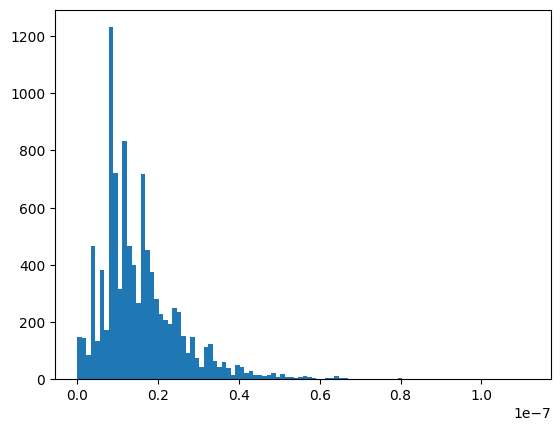

In [ ]:
true = 0
false = 0
total = 0
mean_pos = 0
k = 0
dists = []
for i in range(10000):
    elem = qm9_dataset[i]
    old_symbols, old_positions = elem['y'], elem['x']
    centroid = np.mean(old_positions.cpu().numpy(), axis=0)
    dists.append(np.linalg.norm(centroid))
    mean_pos = (k * mean_pos + centroid)/(k + 1)
    k = k + 1
    # plot_molecule(old_symbols, old_positions, f'true_data/{i}.png')
print(mean_pos)
plt.hist(dists, bins=100)
plt.show()

In [6]:
from custom_datasets.multimodal_math import EquationsDataset
from utils.tokenizer import VocabTokenizer

eq_tokenizer = VocabTokenizer(vocab={'+', '=', '.', '-'})
eq_dataset = EquationsDataset(eq_tokenizer)
data = eq_dataset[102]
print(data)
print(eq_tokenizer.decode(data['y']))

{'x': tensor([[2.6600],
        [4.7800],
        [1.4600],
        [0.8000],
        [4.9300],
        [1.1800],
        [3.7000],
        [4.0700],
        [3.4200],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000]]), 'y': tensor([0, 0, 1, 3, 1, 0, 0, 1, 2, 4, 4, 4, 4, 4, 4, 4]), 'mask': tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True, False,
        False, False, False, False, False, False])}
++-=-++-.


In [ ]:
for i in range(20):
    elem = eq_dataset[i]
    print(elem['x'])
    print(eq_tokenizer.decode(elem['y']))
    print('--------------------------------')

tensor([[5.],
        [5.],
        [9.],
        [2.],
        [9.],
        [9.],
        [2.],
        [5.]])
+++=+-+.
--------------------------------
tensor([[2.],
        [1.],
        [5.],
        [4.],
        [1.],
        [1.],
        [6.]])
+-=+--.
--------------------------------
tensor([[ 4.],
        [ 3.],
        [10.],
        [ 6.],
        [ 6.],
        [ 8.],
        [ 9.],
        [ 2.]])
+--=--+.
--------------------------------
tensor([[2.],
        [1.],
        [4.],
        [7.],
        [7.],
        [2.],
        [9.],
        [4.]])
--+=+-+.
--------------------------------
tensor([[ 2.],
        [10.],
        [ 2.],
        [ 7.],
        [ 9.],
        [ 2.],
        [10.],
        [ 6.]])
+--=--+.
--------------------------------
tensor([[5.],
        [2.],
        [2.],
        [3.],
        [9.],
        [4.],
        [5.],
        [2.]])
+--=--+.
--------------------------------
tensor([[3.],
        [3.],
        [2.],
        [5.],
        [9.],


Ours
{'L': 1, 'n_samples': 10100, 'length_ks_vs_gt': 0.03444514851485153, 'mean_abs_error': 0.1683816500267432, 'median_abs_error': 0.11754026263952255, 'valid_abs_error_frac': 0.9908910891089109}
{'L': 3, 'n_samples': 10100, 'length_ks_vs_gt': 0.01816336633663368, 'mean_abs_error': 0.4232917042924383, 'median_abs_error': 0.31769202277064323, 'valid_abs_error_frac': 0.9954455445544554}
{'L': 5, 'n_samples': 10100, 'length_ks_vs_gt': 0.17381029702970308, 'mean_abs_error': 0.9321585918489002, 'median_abs_error': 0.7657362520694733, 'valid_abs_error_frac': 0.9946534653465346}
{'L': 8, 'n_samples': 10100, 'length_ks_vs_gt': 0.21499999999999997, 'mean_abs_error': 2.085829746465578, 'median_abs_error': 1.5127463340759277, 'valid_abs_error_frac': 0.9855445544554455}
{'L': 10, 'n_samples': 10100, 'length_ks_vs_gt': 0.10632712871287131, 'mean_abs_error': 1.5693829275738496, 'median_abs_error': 1.1120668649673462, 'valid_abs_error_frac': 0.9913861386138614}

Branching Flows
{'L': 1, 'n_samples'

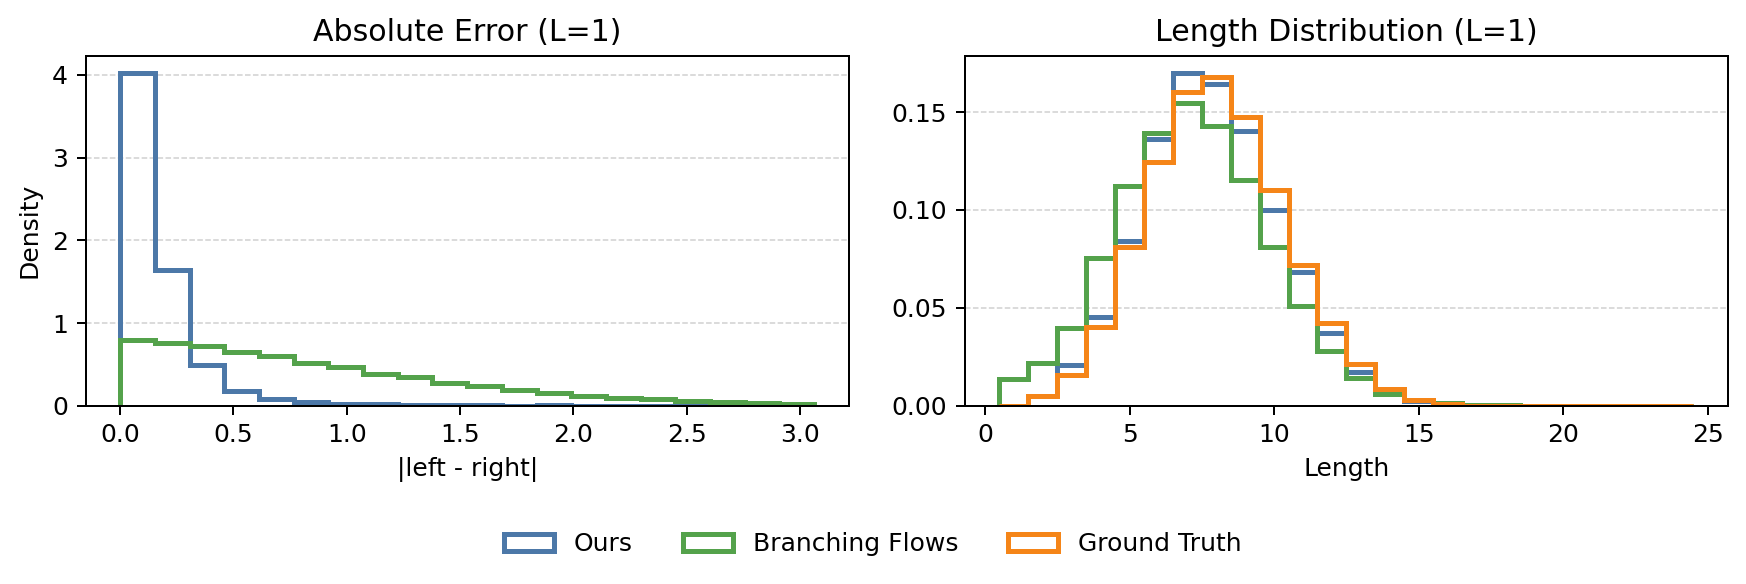

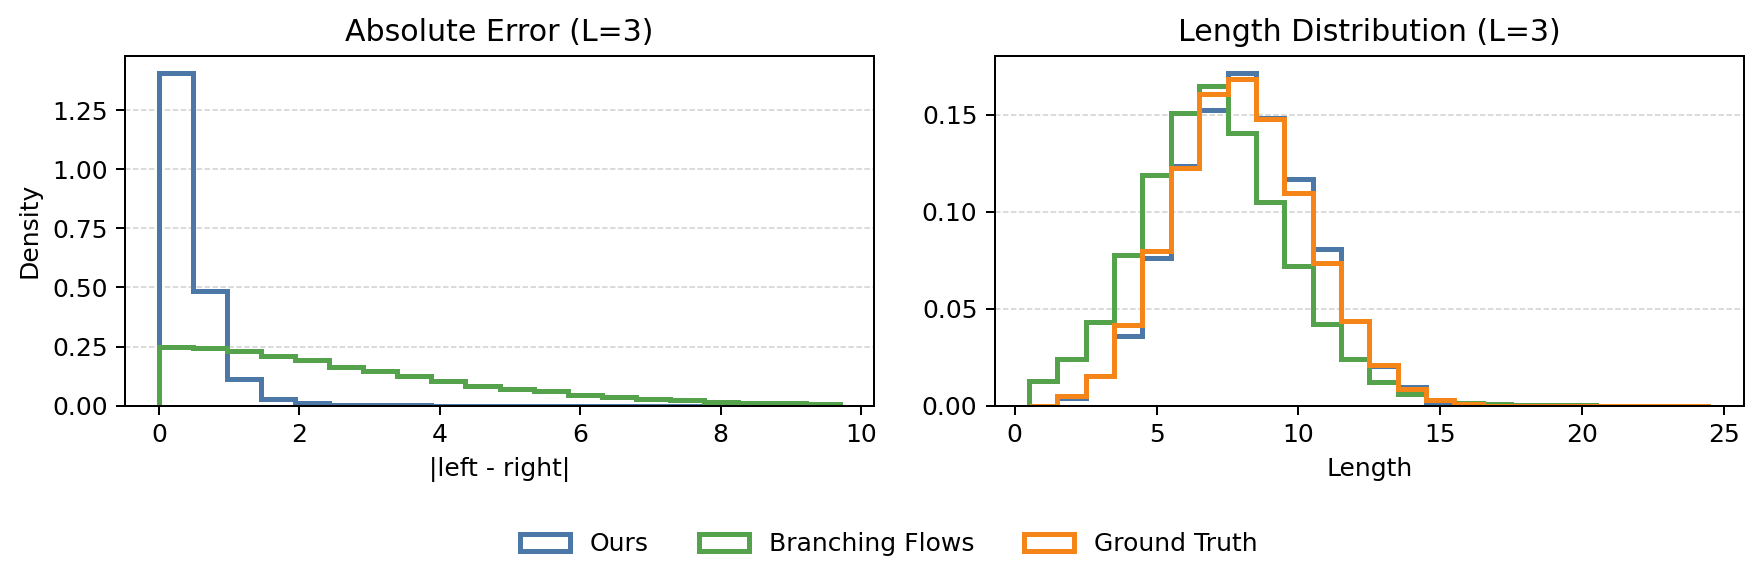

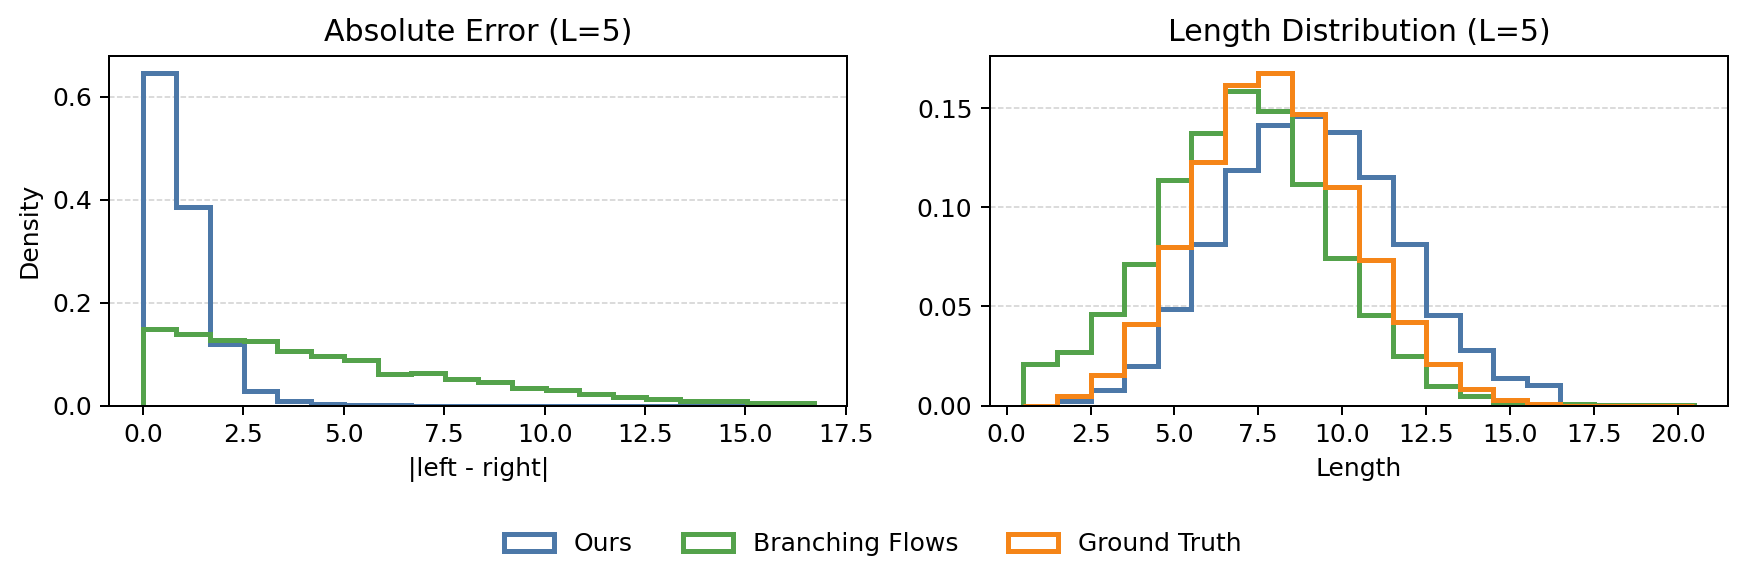

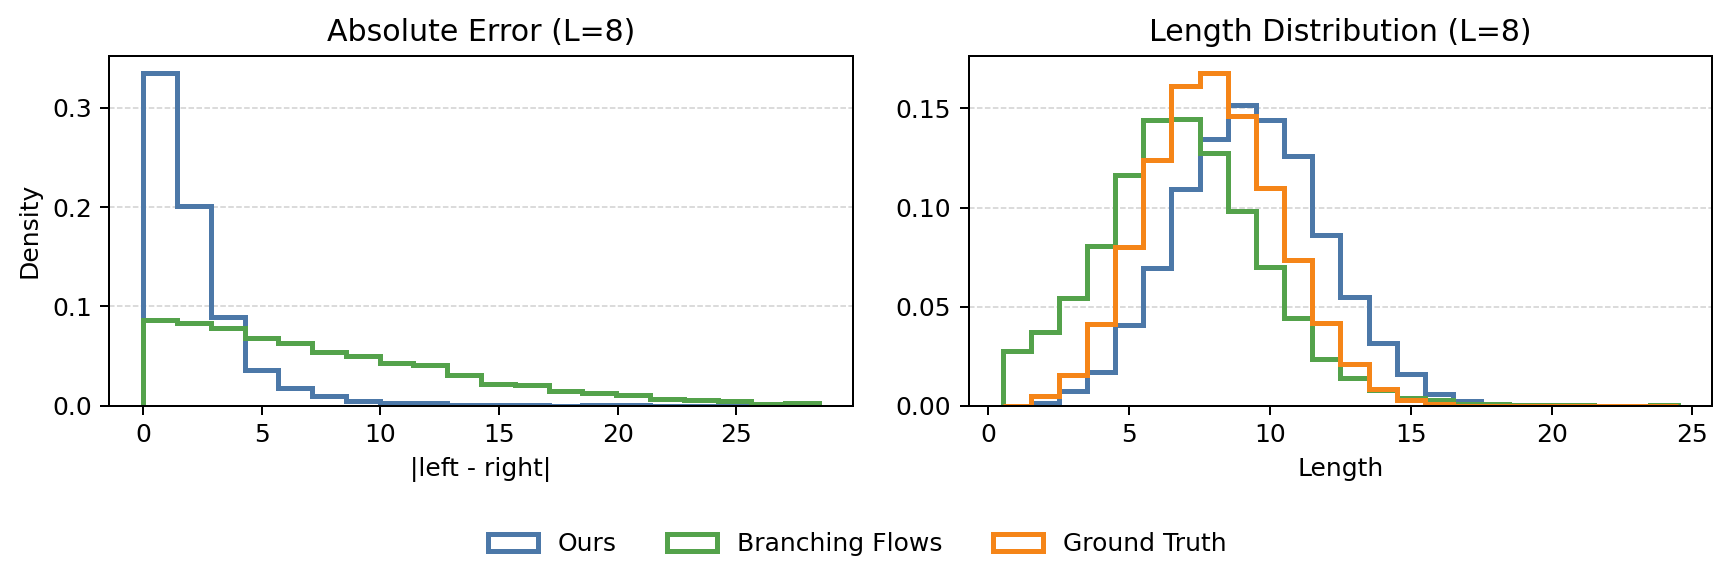

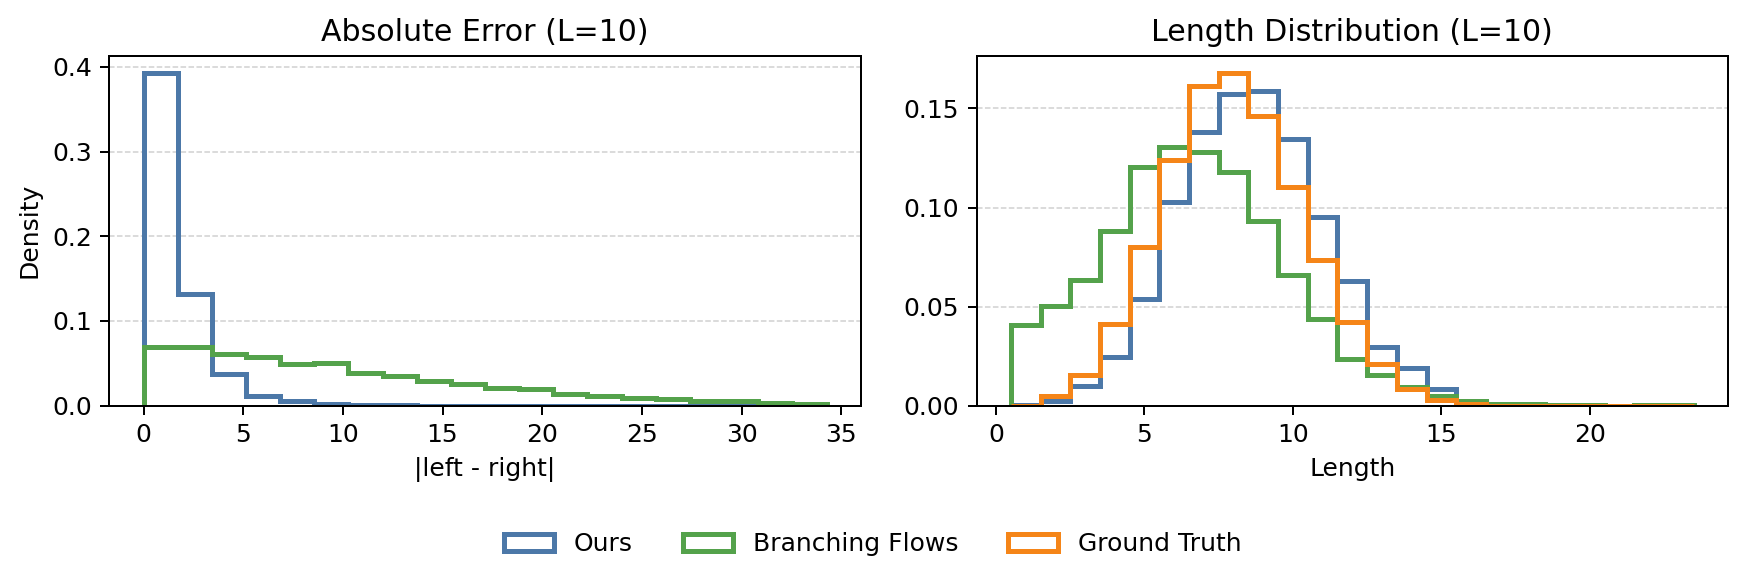

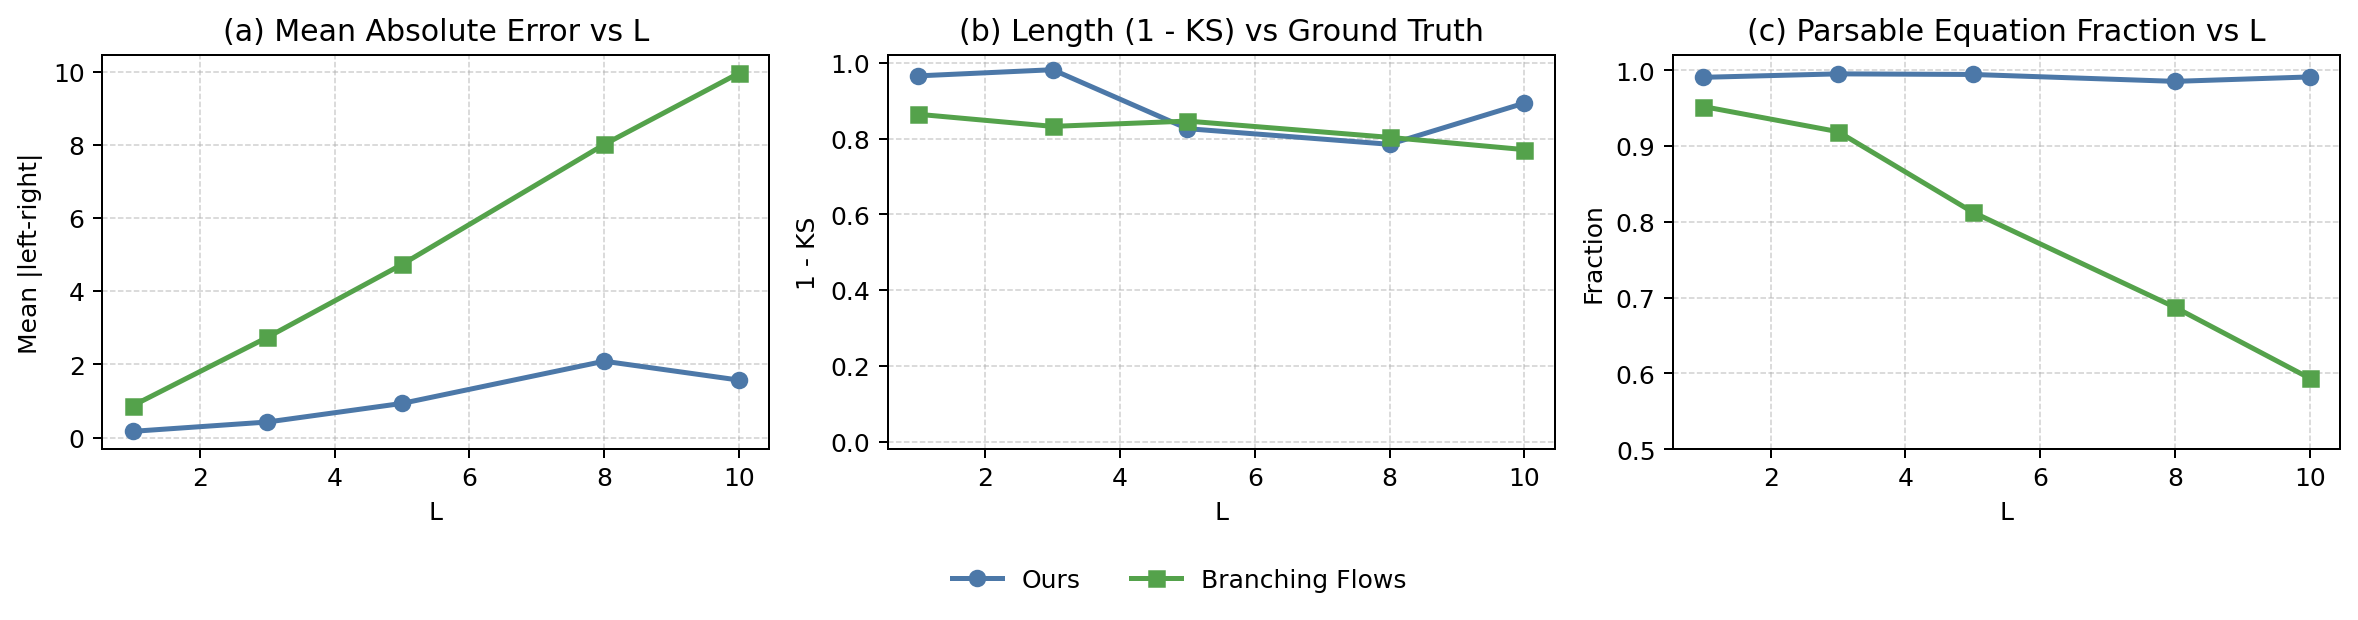

In [34]:
import re
from pathlib import Path

from evaluate_equations import (
    count_equation_symbols,
    parse_equation as parse_equation_linear,
)

L_VALUES = [1, 3, 5, 8, 10]

branching_flow_files = [f"branching_flows_samples/equations_l{i}_gen.jsonl" for i in L_VALUES]
our_files = [f"samples_toy/equations_l{i}/samples.jsonl" for i in L_VALUES]
data_files = [f"data/equations_l{i}.jsonl" for i in L_VALUES]


def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def extract_l_from_path(path):
    text = str(path)
    m = re.search(r"equations_l(\d+)", text)
    if m:
        return int(m.group(1))
    m = re.search(r"/l(\d+)/", text)
    if m:
        return int(m.group(1))
    raise ValueError(f"Could not infer L from path: {path}")


def equation_length(sample):
    symbols = sample.get("symbols", [])
    if symbols:
        return count_equation_symbols(symbols)

    if "length" in sample:
        return int(sample["length"])

    numbers = sample.get("numbers", [])
    return len(numbers)


def equation_abs_error(sample):
    symbols = sample.get("symbols", [])
    positions = sample.get("positions", sample.get("numbers", []))

    if not symbols or not positions:
        return None

    try:
        left_value, right_value = parse_equation_linear(
            symbols,
            positions,
            ignore_trailing_ops=True,
        )
    except Exception:
        return None

    diff = abs(left_value - right_value)
    # Numerical noise from floating-point arithmetic should count as exact.
    if diff < 1e-10:
        return 0.0
    return diff


def collect_metrics_by_l(file_paths):
    out = {}
    for path in file_paths:
        l_value = extract_l_from_path(path)
        samples = load_jsonl(path)
        lengths = [equation_length(s) for s in samples]
        abs_errors = []
        for s in samples:
            err = equation_abs_error(s)
            if err is not None:
                abs_errors.append(err)

        out[l_value] = {
            "path": str(Path(path)),
            "n_samples": len(samples),
            "lengths": np.asarray(lengths, dtype=float),
            "abs_errors": np.asarray(abs_errors, dtype=float),
        }
    return out


def ks_2sample_statistic(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan

    x = np.sort(x)
    y = np.sort(y)
    all_values = np.unique(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_values, side="right") / x.size
    cdf_y = np.searchsorted(y, all_values, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))


def summarize_method(metrics_by_l, gt_metrics_by_l=None):
    rows = []
    for l_value in sorted(metrics_by_l.keys()):
        row = metrics_by_l[l_value]
        lengths = row["lengths"]
        abs_errors = row["abs_errors"]

        length_ks_vs_gt = np.nan
        if gt_metrics_by_l is not None and l_value in gt_metrics_by_l:
            gt_lengths = gt_metrics_by_l[l_value]["lengths"]
            length_ks_vs_gt = ks_2sample_statistic(lengths, gt_lengths)

        rows.append({
            "L": l_value,
            "n_samples": int(row["n_samples"]),
            "length_ks_vs_gt": length_ks_vs_gt,
            "mean_abs_error": float(np.mean(abs_errors)) if abs_errors.size else np.nan,
            "median_abs_error": float(np.median(abs_errors)) if abs_errors.size else np.nan,
            "valid_abs_error_frac": float(abs_errors.size / row["n_samples"]) if row["n_samples"] else np.nan,
        })
    return rows


def plot_comparison_for_l(all_metrics, l_value, bins_abs=20):
    fig, axes = plt.subplots(ncols=2, figsize=(9.8, 3.2), dpi=180)

    colors = {
        "Ours": "#4C78A8",
        "Branching Flows": "#54A24B",
        "Ground Truth": "#F58518",
    }

    # Use line-only histograms for all methods for easier comparison.
    line_style = {
        "Ours": "-",
        "Branching Flows": "-",
        "Ground Truth": "-",
    }

    # Absolute error histogram (no Ground Truth curve)
    ax = axes[0]
    abs_methods = ["Ours", "Branching Flows"]
    max_diff_candidates = []
    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size:
            max_diff_candidates.append(float(np.quantile(errors, 0.99)))

    max_diff = max(max_diff_candidates) if max_diff_candidates else 1.0
    max_diff = max(max_diff, 1e-6)

    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size == 0:
            continue

        ax.hist(
            errors,
            bins=bins_abs,
            range=(0, max_diff),
            density=True,
            histtype="step",
            color=colors[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )

    if not max_diff_candidates:
        ax.text(0.5, 0.5, "No valid equations parsed", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"Absolute Error (L={l_value})")
    ax.set_xlabel("|left - right|")
    ax.set_ylabel("Density")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    # Length histogram
    ax = axes[1]
    max_len = 1
    for method_name in colors.keys():
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size:
            max_len = max(max_len, int(np.max(lengths)))
    bins = np.arange(1, max_len + 2) - 0.5

    for method_name in colors.keys():
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size == 0:
            continue

        ax.hist(
            lengths,
            bins=bins,
            density=True,
            histtype="step",
            color=colors[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )

    bf_len = all_metrics["Branching Flows"][l_value]["lengths"]
    gt_len = all_metrics["Ground Truth"][l_value]["lengths"]
    if bf_len.size and gt_len.size and np.array_equal(bf_len, gt_len):
        ax.text(0.98, 0.95, "BF and GT overlap exactly", ha="right", va="top", fontsize=9, transform=ax.transAxes)

    ax.set_title(f"Length Distribution (L={l_value})")
    ax.set_xlabel("Length")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)
    # plt.show()
    plt.savefig(f"plots/l{l_value}.pdf")


def plot_trends_vs_l(all_metrics):
    fig, axes = plt.subplots(ncols=3, figsize=(13.2, 3.4), dpi=180)

    styles = {
        "Ours": ("#4C78A8", "o"),
        "Branching Flows": ("#54A24B", "s"),
        "Ground Truth": ("#F58518", "^")
    }

    gt_metrics = all_metrics["Ground Truth"]

    for method_name, (color, marker) in styles.items():
        summary = summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics)
        ls = [r["L"] for r in summary]
        mean_abs = [r["mean_abs_error"] for r in summary]
        length_ks = [r["length_ks_vs_gt"] for r in summary]
        length_one_minus_ks = [1.0 - v if np.isfinite(v) else np.nan for v in length_ks]
        valid_frac = [r["valid_abs_error_frac"] for r in summary]

        if method_name != "Ground Truth":
            axes[0].plot(ls, mean_abs, marker=marker, color=color, linewidth=2, label=method_name)
            axes[1].plot(ls, length_one_minus_ks, marker=marker, color=color, linewidth=2, label=method_name)
            axes[2].plot(ls, valid_frac, marker=marker, color=color, linewidth=2, label=method_name)

    axes[0].set_title("(a) Mean Absolute Error vs L")
    axes[0].set_xlabel("L")
    axes[0].set_ylabel("Mean |left-right|")

    axes[1].set_title("(b) Length (1 - KS) vs Ground Truth")
    axes[1].set_xlabel("L")
    axes[1].set_ylabel("1 - KS")
    axes[1].set_ylim(-0.02, 1.02)

    axes[2].set_title("(c) Parsable Equation Fraction vs L")
    axes[2].set_xlabel("L")
    axes[2].set_ylabel("Fraction")
    axes[2].set_ylim(0.5, 1.02)

    for ax in axes:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    # plt.show()
    plt.savefig(f"plots/l_trends.pdf")



all_metrics = {
    "Ours": collect_metrics_by_l(our_files),
    "Branching Flows": collect_metrics_by_l(branching_flow_files),
    "Ground Truth": collect_metrics_by_l(data_files),
}

# Per-L comparisons (same style of side-by-side comparisons you made above)
for l_value in [1, 3, 5, 8, 10]:
    plot_comparison_for_l(all_metrics, l_value)

# Trends as a function of L
plot_trends_vs_l(all_metrics)

# Optional: quick tabular summaries
gt_metrics = all_metrics["Ground Truth"]
for method_name in ["Ours", "Branching Flows", "Ground Truth"]:
    print(f"\n{method_name}")
    for row in summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics):
        print(row)

In [ ]:
our_files = [f"samples-parenthesis/l{i}/samples.jsonl" for i in L_VALUES]
data_files = [f"data/parenthesis/equations_l{i}.jsonl" for i in L_VALUES]

In [31]:
import re
from pathlib import Path

from evaluate_equations_parenthesis import (
    count_equation_symbols as count_equation_symbols_parenthesis,
    parse_equation as parse_equation_parenthesis,
)


def load_jsonl_parenthesis(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def equation_length_parenthesis(sample):
    symbols = sample.get("symbols", [])
    if symbols:
        return count_equation_symbols_parenthesis(symbols)
    if "length" in sample:
        return int(sample["length"])
    return len(sample.get("numbers", []))


def equation_abs_error_parenthesis(sample):
    symbols = sample.get("symbols", [])
    positions = sample.get("positions", sample.get("numbers", []))
    if not symbols or not positions:
        return None

    try:
        left, right = parse_equation_parenthesis(
            symbols,
            positions,
            ignore_trailing_ops=True,
        )
    except Exception:
        return None

    diff = abs(left - right)
    if diff < 1e-10:
        return 0.0
    return diff


def collect_metrics_by_l_parenthesis(files_by_l):
    out = {}
    for l_value, path in sorted(files_by_l.items()):
        samples = load_jsonl_parenthesis(path)
        lengths = [equation_length_parenthesis(s) for s in samples]
        abs_errors = []
        for s in samples:
            err = equation_abs_error_parenthesis(s)
            if err is not None:
                abs_errors.append(err)

        out[l_value] = {
            "path": str(path),
            "n_samples": len(samples),
            "lengths": np.asarray(lengths, dtype=float),
            "abs_errors": np.asarray(abs_errors, dtype=float),
        }
    return out


def ks_2sample_statistic_parenthesis(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan

    x = np.sort(x)
    y = np.sort(y)
    all_values = np.unique(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_values, side="right") / x.size
    cdf_y = np.searchsorted(y, all_values, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))


def summarize_method_parenthesis(metrics_by_l, gt_metrics_by_l):
    rows = []
    for l_value in sorted(metrics_by_l.keys()):
        row = metrics_by_l[l_value]
        lengths = row["lengths"]
        abs_errors = row["abs_errors"]
        gt_lengths = gt_metrics_by_l[l_value]["lengths"]

        ks = ks_2sample_statistic_parenthesis(lengths, gt_lengths)
        rows.append({
            "L": l_value,
            "n_samples": int(row["n_samples"]),
            "length_ks_vs_gt": ks,
            "length_1_minus_ks": (1.0 - ks) if np.isfinite(ks) else np.nan,
            "mean_abs_error": float(np.mean(abs_errors)) if abs_errors.size else np.nan,
            "median_abs_error": float(np.median(abs_errors)) if abs_errors.size else np.nan,
            "valid_abs_error_frac": float(abs_errors.size / row["n_samples"]) if row["n_samples"] else np.nan,
        })
    return rows


def plot_comparison_for_l_parenthesis(all_metrics, l_value, bins_abs=20):
    fig, axes = plt.subplots(ncols=2, figsize=(9.8, 3.2), dpi=180)

    colors = {
        "Ours": "#4C78A8",
        "Ground Truth": "#F58518",
    }
    line_style = {
        "Ours": "-",
        "Ground Truth": "--",
    }

    # Absolute error histogram (exclude Ground Truth)
    ax = axes[0]
    abs_methods = ["Ours"]
    max_diff_candidates = []
    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size:
            max_diff_candidates.append(float(np.quantile(errors, 0.99)))

    max_diff = max(max_diff_candidates) if max_diff_candidates else 1.0
    max_diff = max(max_diff, 1e-6)

    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size == 0:
            continue
        ax.hist(
            errors,
            bins=bins_abs,
            range=(0, max_diff),
            density=True,
            histtype="step",
            color=colors[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )

    if not max_diff_candidates:
        ax.text(0.5, 0.5, "No valid equations parsed", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"Absolute Error (L={l_value})")
    ax.set_xlabel("|left - right|")
    ax.set_ylabel("Density")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    # Length histogram
    ax = axes[1]
    max_len = 1
    for method_name in colors.keys():
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size:
            max_len = max(max_len, int(np.max(lengths)))
    bins = np.arange(1, max_len + 2) - 0.5

    for method_name in colors.keys():
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size == 0:
            continue
        ax.hist(
            lengths,
            bins=bins,
            density=True,
            histtype="step",
            color=colors[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )

    ax.set_title(f"Length Distribution (L={l_value})")
    ax.set_xlabel("Length")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    # plt.show()
    plt.savefig(f"plots/parenthesis_l{l_value}.png")


def plot_trends_vs_l_parenthesis(all_metrics):
    fig, axes = plt.subplots(ncols=3, figsize=(13.2, 3.4), dpi=180)

    styles = {
        "Ours": ("#4C78A8", "o"),
        "Ground Truth": ("#F58518", "^")
    }

    gt_metrics = all_metrics["Ground Truth"]

    for method_name, (color, marker) in styles.items():
        summary = summarize_method_parenthesis(all_metrics[method_name], gt_metrics)
        ls = [r["L"] for r in summary]
        mean_abs = [r["mean_abs_error"] for r in summary]
        length_1mks = [r["length_1_minus_ks"] for r in summary]
        valid_frac = [r["valid_abs_error_frac"] for r in summary]

        axes[0].plot(ls, mean_abs, marker=marker, color=color, linewidth=2, label=method_name)
        if method_name != "Ground Truth":
            axes[1].plot(ls, length_1mks, marker=marker, color=color, linewidth=2, label=method_name)
        axes[2].plot(ls, valid_frac, marker=marker, color=color, linewidth=2, label=method_name)

    axes[0].set_title("Mean Absolute Error vs L")
    axes[0].set_xlabel("L")
    axes[0].set_ylabel("Mean |left-right|")

    axes[1].set_title("Length (1 - KS) vs Ground Truth")
    axes[1].set_xlabel("L")
    axes[1].set_ylabel("1 - KS")
    axes[1].set_ylim(-0.02, 1.02)

    axes[2].set_title("Parsable Equation Fraction vs L")
    axes[2].set_xlabel("L")
    axes[2].set_ylabel("Fraction")
    axes[2].set_ylim(0.0, 1.02)

    for ax in axes:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    # plt.show()
    plt.savefig(f"plots/parenthesis_l.png")


L_VALUES_PARENT = [5,10]
our_parent_files = {l: f"samples-parenthesis/l{l}/samples.jsonl" for l in L_VALUES_PARENT}
gt_parent_files = {l: f"data/parenthesis/equations_l{l}.jsonl" for l in L_VALUES_PARENT}

all_metrics_parenthesis = {
    "Ours": collect_metrics_by_l_parenthesis(our_parent_files),
    "Ground Truth": collect_metrics_by_l_parenthesis(gt_parent_files),
}

print("Parenthesis L values:", L_VALUES_PARENT)

for l_value in L_VALUES_PARENT:
    plot_comparison_for_l_parenthesis(all_metrics_parenthesis, l_value)

plot_trends_vs_l_parenthesis(all_metrics_parenthesis)

print("\nOurs")
for row in summarize_method_parenthesis(all_metrics_parenthesis["Ours"], all_metrics_parenthesis["Ground Truth"]):
    print(row)

print("\nGround Truth")
for row in summarize_method_parenthesis(all_metrics_parenthesis["Ground Truth"], all_metrics_parenthesis["Ground Truth"]):
    print(row)


NameError: name 'np' is not defined

,family,method,L,n_samples,valid_rate,accuracy_over_all,mean_abs_error,median_abs_error
0,linear,Branching Flows,1,49410,0.952317,0.354584,0.867660,0.704185
5,linear,Ground Truth,1,50000,1.000000,1.000000,0.000000,0.000000
10,linear,Ours,1,10100,0.990891,0.942970,0.168382,0.117540
1,linear,Branching Flows,3,46773,0.919141,0.111817,2.737770,2.211569
6,linear,Ground Truth,3,50000,1.000000,1.000000,0.000000,0.000000
11,linear,Ours,3,10100,0.995446,0.691089,0.423292,0.317692
2,linear,Branching Flows,5,9657,0.812882,0.063063,4.731096,3.837627
7,linear,Ground Truth,5,50000,1.000000,1.000000,0.000000,0.000000
12,linear,Ours,5,10100,0.994653,0.336040,0.932159,0.765736
3,linear,Branching Flows,8,9357,0.687400,0.031741,8.009254,6.535340


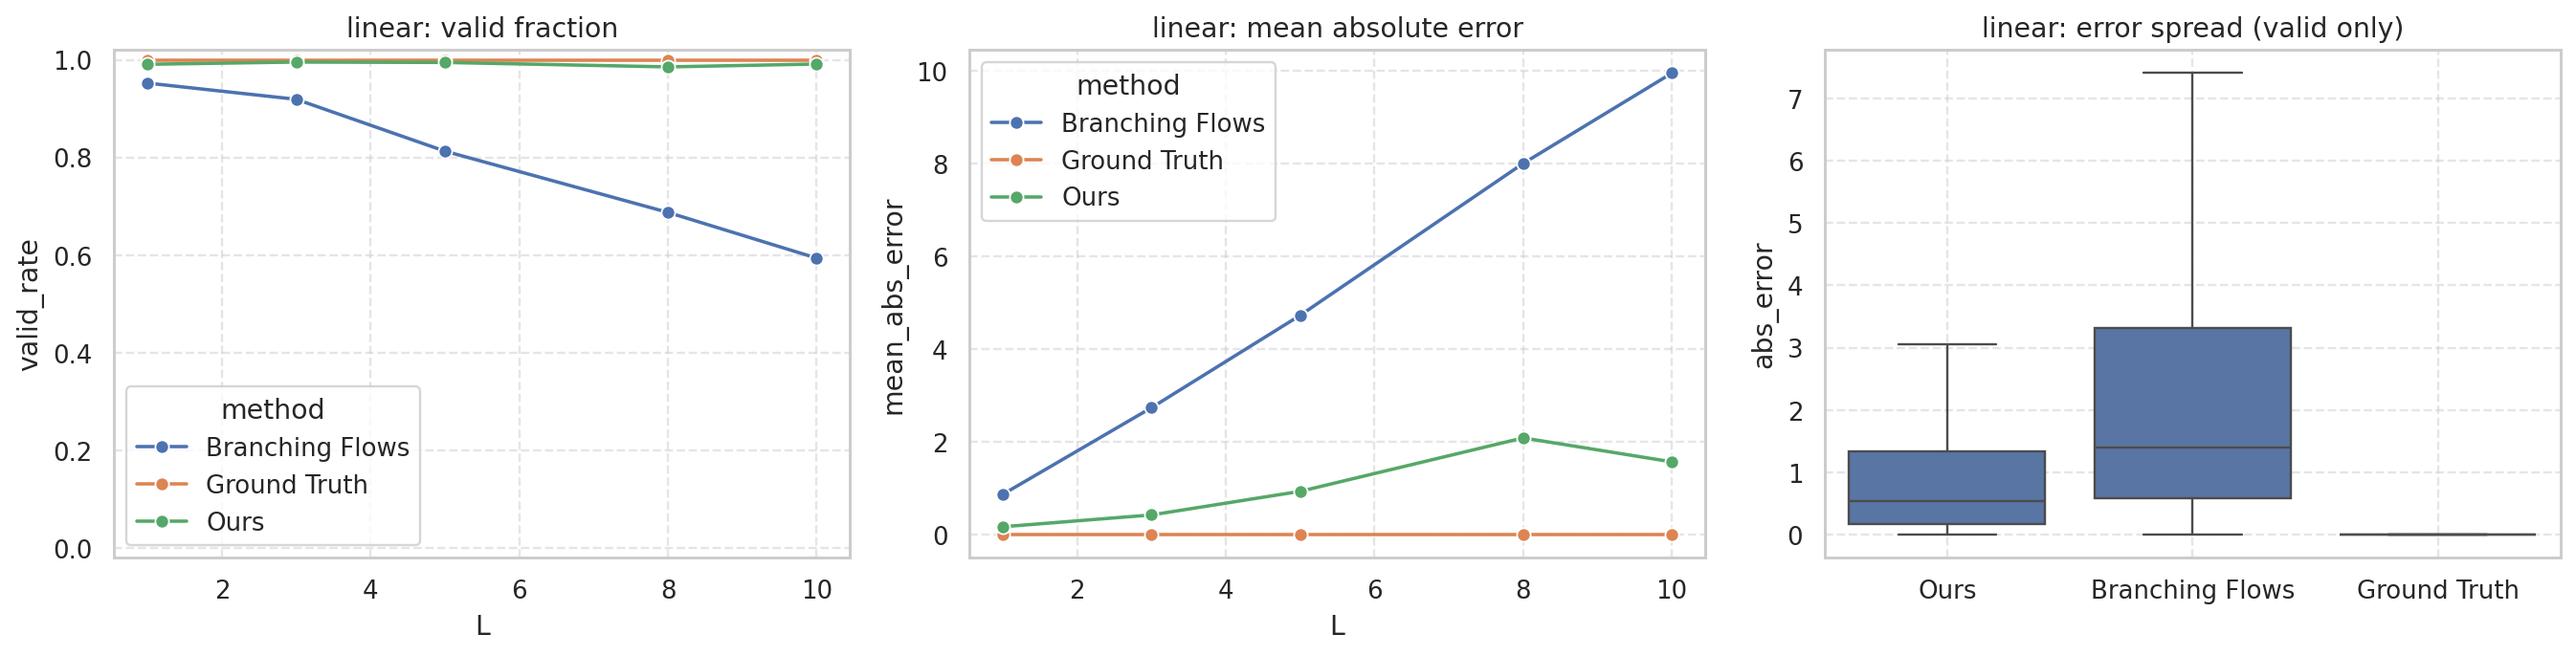

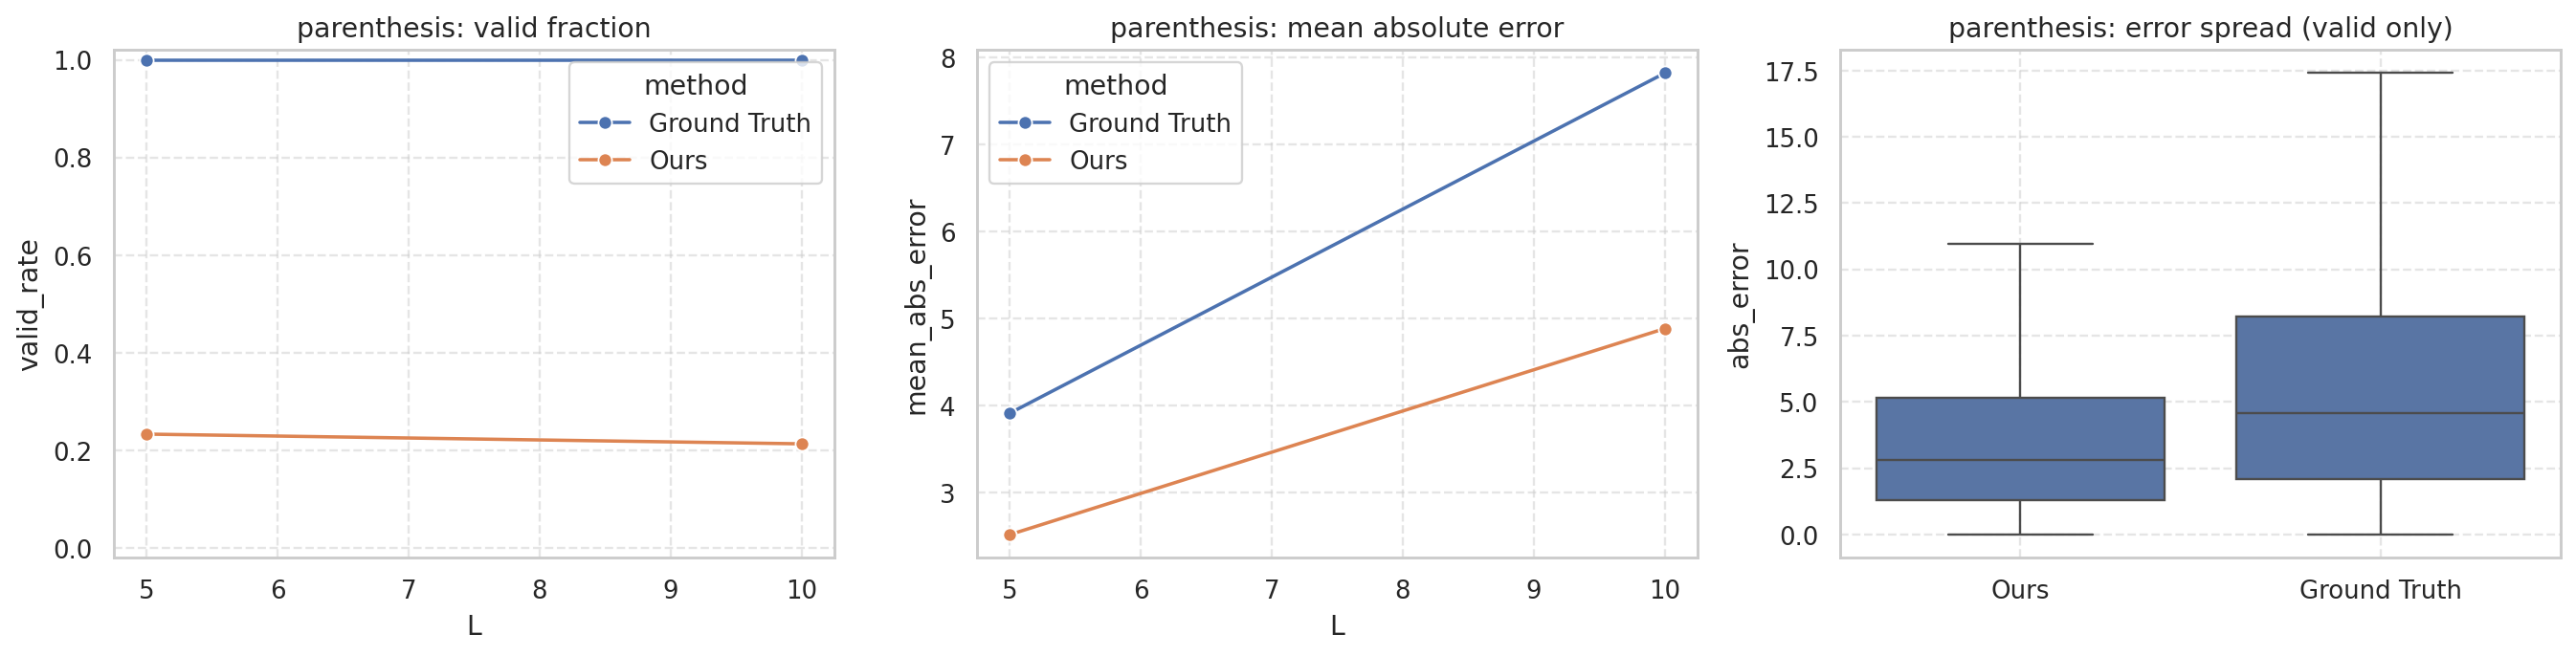


Top failure cases (invalid first, then largest error):

[linear] Branching Flows


,L,idx,valid,correct,abs_error
50526,1,26,False,False,NaN
50530,1,30,False,False,NaN
50535,1,35,False,False,NaN
50613,1,113,False,False,NaN
50654,1,154,False,False,NaN
50662,1,162,False,False,NaN
50671,1,171,False,False,NaN
50678,1,178,False,False,NaN


  - -+. | nums=[-0.018, 0.753, 0.06]
  - +. | nums=[-0.685, 0.477]
  - -+. | nums=[0.416, 0.733, 0.42]
  - -. | nums=[0.606, 0.443]

[linear] Ground Truth: no failures

[linear] Ours


,L,idx,valid,correct,abs_error
6,1,6,False,False,NaN
78,1,78,False,False,NaN
98,1,98,False,False,NaN
149,1,149,False,False,NaN
188,1,188,False,False,NaN
804,1,804,False,False,NaN
1039,1,1039,False,False,NaN
1147,1,1147,False,False,NaN


  - ++--+==+. | nums=[-0.245, 0.099, 0.927, 0.413, 0.403, 0.737, -0.077, -0.477] ...
  - +--++--. | nums=[-0.049, 0.516, 0.433, 0.41, 0.027, 0.601, 0.751, 0.397]
  - --++==--+--+. | nums=[-0.131, 0.827, 0.234, 0.298, 0.458, 0.472, -0.394, 0.898] ...
  - +-++-+-. | nums=[0.27, 0.36, 0.21, 0.289, 0.321, 0.207, 0.786, 0.382]

[parenthesis] Ground Truth


,L,idx,valid,correct,abs_error
542256,10,46971,True,False,36.71
523807,10,28522,True,False,36.62
537221,10,41936,True,False,35.26
522821,10,27536,True,False,35.14
517470,10,22185,True,False,35.06
518192,10,22907,True,False,34.92
522540,10,27255,True,False,34.85
513840,10,18555,True,False,34.76


  - +(-)+=(-)+(-)-. | nums=[-7.14, 9.27, 7.51, 5.34, 7.45, 7.87, 8.31, 1.53] ...
  - (-)+(--)+=(-)-. | nums=[-8.55, 4.11, 8.42, 9.69, 5.85, 5.55, -6.43, 6.9] ...
  - (-)+(+)--=(---)-. | nums=[-8.34, 6.74, 2.21, 9.79, 8.18, 3.46, 9.2, 8.74] ...
  - (-)+(-)-=--+(++). | nums=[9.33, 7.85, 9.36, 8.6, 6.81, -5.74, 9.0, 5.15] ...

[parenthesis] Ours


,L,idx,valid,correct,abs_error
425085,5,0,False,False,NaN
425086,5,1,False,False,NaN
425088,5,3,False,False,NaN
425089,5,4,False,False,NaN
425092,5,7,False,False,NaN
425093,5,8,False,False,NaN
425094,5,9,False,False,NaN
425095,5,10,False,False,NaN


  - )=+(++-)-.-).()+. | nums=[1.765, 3.166, 2.094, 2.504, 1.863, 2.679, 2.361, 2.255] ...
  - (--)++)+=.. | nums=[1.549, 1.718, 2.666, 1.445, 2.264, 0.873, 2.493]
  - ()-(--(-).-+(-)-.-.. | nums=[-0.044, 2.346, 3.529, 1.324, 1.797, 1.269, 2.905, 2.929] ...
  - ++(-).+)-+.+(-).+.). | nums=[0.72, 1.956, 1.412, 1.964, 2.665, 2.824, 2.257, 1.959] ...


In [35]:
# Integrated visualization: dataset vs generated, plus qualitative failure cases
# This cell reuses the paths/functions you already defined in Cells 7 and 9.

import os
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


def _safe_extract_number(x):
    if isinstance(x, (list, tuple)):
        if len(x) == 0:
            return float("nan")
        return float(x[0])
    return float(x)


def _safe_symbols(sample):
    symbols = sample.get("symbols", [])
    if isinstance(symbols, str):
        return [ch for ch in symbols if ch.strip()]
    return list(symbols)


def _preview(sample):
    symbols = "".join(_safe_symbols(sample))
    nums = sample.get("positions", sample.get("numbers", []))
    nums = [_safe_extract_number(v) for v in nums]
    short = [round(v, 3) for v in nums[:8]]
    suffix = " ..." if len(nums) > 8 else ""
    return f"{symbols} | nums={short}{suffix}"


def _rows_from_files_linear(method_name, file_paths):
    rows = []
    for path in file_paths:
        if not os.path.exists(path):
            print(f"[warn] missing file: {path}")
            continue

        L = extract_l_from_path(path)
        samples = load_jsonl(path)
        for idx, s in enumerate(samples):
            symbols = _safe_symbols(s)
            positions = s.get("positions", s.get("numbers", []))

            err = equation_abs_error(s)
            valid = err is not None
            correct = valid and (err < 0.5)

            rows.append({
                "family": "linear",
                "method": method_name,
                "L": L,
                "idx": idx,
                "valid": valid,
                "correct": correct,
                "abs_error": float(err) if err is not None else np.nan,
                "eq_len": equation_length(s),
                "parse_error": "" if valid else "parse_failed",
                "sample": s,
            })
    return rows


def _rows_from_files_parenthesis(method_name, files_by_l):
    rows = []
    for L, path in sorted(files_by_l.items()):
        if not os.path.exists(path):
            print(f"[warn] missing file: {path}")
            continue

        samples = load_jsonl_parenthesis(path)
        for idx, s in enumerate(samples):
            err = equation_abs_error_parenthesis(s)
            valid = err is not None
            correct = valid and (err < 0.5)

            rows.append({
                "family": "parenthesis",
                "method": method_name,
                "L": int(L),
                "idx": idx,
                "valid": valid,
                "correct": correct,
                "abs_error": float(err) if err is not None else np.nan,
                "eq_len": equation_length_parenthesis(s),
                "parse_error": "" if valid else "parse_failed",
                "sample": s,
            })
    return rows


# Build one joined dataframe from already-defined experiment paths.
rows = []

# Linear experiment from Cell 7
if "our_files" in globals() and isinstance(our_files, list):
    rows += _rows_from_files_linear("Ours", our_files)
if "branching_flow_files" in globals() and isinstance(branching_flow_files, list):
    rows += _rows_from_files_linear("Branching Flows", branching_flow_files)
if "data_files" in globals() and isinstance(data_files, list):
    rows += _rows_from_files_linear("Ground Truth", data_files)

# Parenthesis experiment from Cell 9
if "our_parent_files" in globals() and isinstance(our_parent_files, dict):
    rows += _rows_from_files_parenthesis("Ours", our_parent_files)
if "gt_parent_files" in globals() and isinstance(gt_parent_files, dict):
    rows += _rows_from_files_parenthesis("Ground Truth", gt_parent_files)

if len(rows) == 0:
    raise RuntimeError("No rows collected. Run cells 7/9 first (or check sample file paths).")

viz_df = pd.DataFrame(rows)


# -----------------------------
# Summary tables
# -----------------------------
summary = (
    viz_df.groupby(["family", "method", "L"], as_index=False)
    .agg(
        n_samples=("idx", "count"),
        valid_rate=("valid", "mean"),
        accuracy_over_all=("correct", "mean"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
    )
)

display(summary.sort_values(["family", "L", "method"]))


# -----------------------------
# Plots per family
# -----------------------------
for family_name in sorted(viz_df["family"].unique()):
    family_df = viz_df[viz_df["family"] == family_name].copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=170)

    sns.lineplot(
        data=summary[summary["family"] == family_name],
        x="L",
        y="valid_rate",
        hue="method",
        marker="o",
        ax=axes[0],
    )
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].set_title(f"{family_name}: valid fraction")

    sns.lineplot(
        data=summary[summary["family"] == family_name],
        x="L",
        y="mean_abs_error",
        hue="method",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title(f"{family_name}: mean absolute error")

    sns.boxplot(
        data=family_df[family_df["valid"]],
        x="method",
        y="abs_error",
        ax=axes[2],
        showfliers=False,
    )
    axes[2].set_title(f"{family_name}: error spread (valid only)")
    axes[2].set_xlabel("")

    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# -----------------------------
# Qualitative failure cases
# -----------------------------
print("\nTop failure cases (invalid first, then largest error):")
for family_name in sorted(viz_df["family"].unique()):
    fam_df = viz_df[viz_df["family"] == family_name]
    for method_name in sorted(fam_df["method"].unique()):
        sub = fam_df[fam_df["method"] == method_name].copy()
        failures = sub[(~sub["valid"]) | (~sub["correct"])].copy()
        if failures.empty:
            print(f"\n[{family_name}] {method_name}: no failures")
            continue

        failures["invalid_first"] = (~failures["valid"]).astype(int)
        failures["sort_err"] = failures["abs_error"].fillna(np.inf)
        failures = failures.sort_values(["invalid_first", "sort_err"], ascending=[False, False])

        print(f"\n[{family_name}] {method_name}")
        cols = ["L", "idx", "valid", "correct", "abs_error"]
        display(failures[cols].head(8))

        for _, row in failures.head(4).iterrows():
            print("  -", _preview(row["sample"]))

L=8
{'euler': [{'steps': 500, 'acc-1': 0.33545454545454545, 'acc-2': 0.6136363636363636, 'valid': 1078}, {'steps': 250, 'acc-1': 0.31363636363636366, 'acc-2': 0.5645454545454546, 'valid': 1064}, {'steps': 125, 'acc-1': 0.30636363636363634, 'acc-2': 0.5509090909090909, 'valid': 1048}, {'steps': 75, 'acc-1': 0.2918181818181818, 'acc-2': 0.49454545454545457, 'valid': 1040}, {'steps': 50, 'acc-1': 0.24545454545454545, 'acc-2': 0.44272727272727275, 'valid': 1026}], '2nd-order': [{'steps': 500, 'acc-1': 0.3427272727272727, 'acc-2': 0.6218181818181818, 'valid': 1073}, {'steps': 250, 'acc-1': 0.32636363636363636, 'acc-2': 0.6072727272727273, 'valid': 1080}, {'steps': 125, 'acc-1': 0.33545454545454545, 'acc-2': 0.5709090909090909, 'valid': 1071}, {'steps': 75, 'acc-1': 0.3245454545454545, 'acc-2': 0.5627272727272727, 'valid': 1044}, {'steps': 50, 'acc-1': 0.30272727272727273, 'acc-2': 0.5245454545454545, 'valid': 1047}]}

L=10
{'euler': [{'steps': 500, 'acc-1': 0.4590909090909091, 'acc-2': 0.71

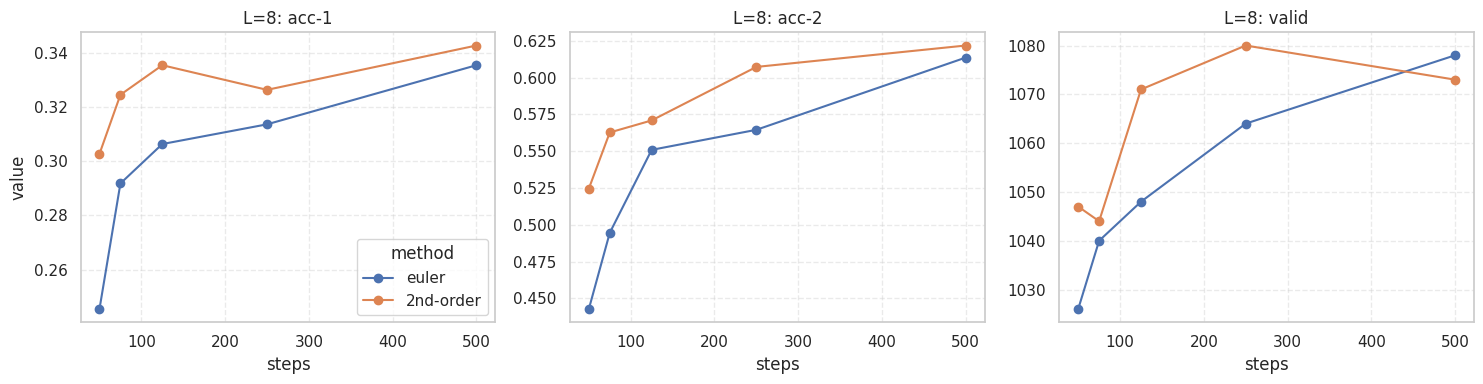

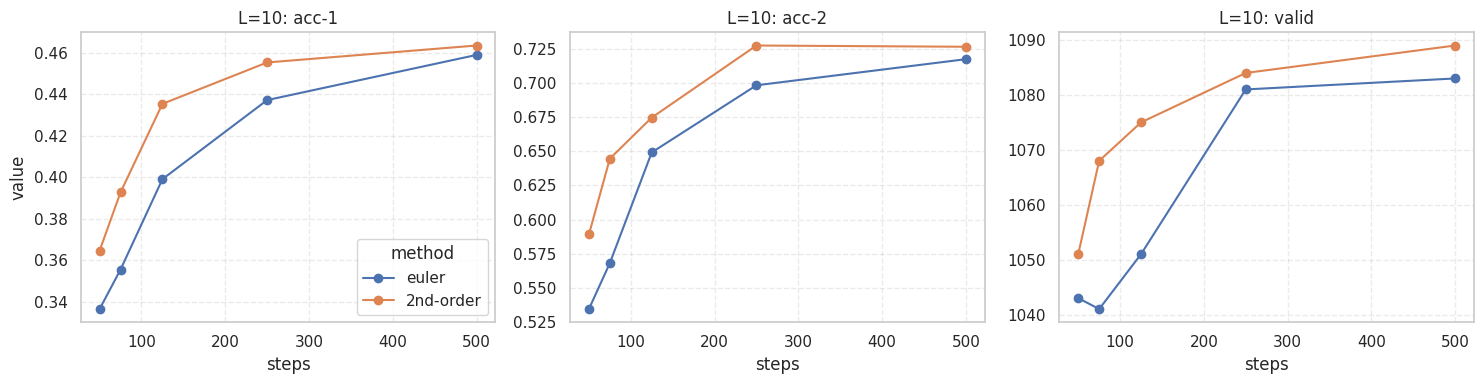

In [38]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if "load_jsonl" not in globals() or "equation_abs_error" not in globals():
    raise RuntimeError("Run the earlier evaluation cells first (load_jsonl/equation_abs_error are required).")

SAMPLES_ROOT = Path("samples_toy")
DELTA_1 = 1.0
DELTA_2 = 2.0


def evaluate_samples_file(path: Path, delta_1: float = DELTA_1, delta_2: float = DELTA_2):
    samples = load_jsonl(path)
    total = len(samples)

    # Reuse existing notebook option: equation_abs_error(sample)
    errors = [equation_abs_error(s) for s in samples]
    valid_errors = [e for e in errors if e is not None]

    correct_1 = sum(e < delta_1 for e in valid_errors)
    correct_2 = sum(e < delta_2 for e in valid_errors)

    return {
        "acc-1": correct_1 / total if total else 0.0,
        "acc-2": correct_2 / total if total else 0.0,
        "valid": len(valid_errors),
    }


def collect_results_for_length(length_value: int):
    method_map = {
        "euler": "euler",
        "2nd-order": "2ndorder",
    }

    out = {"euler": [], "2nd-order": []}

    for method_label, method_key in method_map.items():
        pattern = f"equations_l{length_value}_{method_key}_*/samples.jsonl"
        files = sorted(SAMPLES_ROOT.glob(pattern))

        for path in files:
            m = re.search(r"_(\d+)$", path.parent.name)
            if not m:
                continue
            steps = int(m.group(1))
            metrics = evaluate_samples_file(path)
            out[method_label].append({"steps": steps, **metrics})

    # Keep only steps present for both methods.
    shared_steps = set(r["steps"] for r in out["euler"]) & set(r["steps"] for r in out["2nd-order"])
    for method_label in out:
        out[method_label] = [r for r in out[method_label] if r["steps"] in shared_steps]
        out[method_label] = sorted(out[method_label], key=lambda x: x["steps"], reverse=True)

    return out


results_l8 = collect_results_for_length(8)
results_l10 = collect_results_for_length(10)

print("L=8")
print(results_l8)
print("\nL=10")
print(results_l10)


def plot_results(results_dict, title_prefix=""):
    rows = []
    for method, entries in results_dict.items():
        for entry in entries:
            rows.append({"method": method, **entry})

    if not rows:
        print(f"No rows to plot for {title_prefix}")
        return

    df = pd.DataFrame(rows).sort_values("steps")
    metrics = ["acc-1", "acc-2", "valid"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    for ax, metric in zip(axes, metrics):
        for method in df["method"].unique():
            sub = df[df["method"] == method]
            ax.plot(sub["steps"], sub[metric], marker="o", label=method)

        ax.set_title(f"{title_prefix}{metric}")
        ax.set_xlabel("steps")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].set_ylabel("value")
    axes[0].legend(title="method")
    plt.tight_layout()
    plt.show()


plot_results(results_l8, title_prefix="L=8: ")
plot_results(results_l10, title_prefix="L=10: ")

In [ ]:
# Plot dataset



## Paper Figure: Qualitative Dataset Overview (2x2)

This section builds one publication-ready figure with four panels:

- **A:** Dataset syntax snapshot
- **B:** Real dataset examples (plain and parenthesized)
- **C:** Samples from our method
- **D:** Samples from baseline/other method

The cell below is fully configurable via the `FIG_CFG` dictionary.

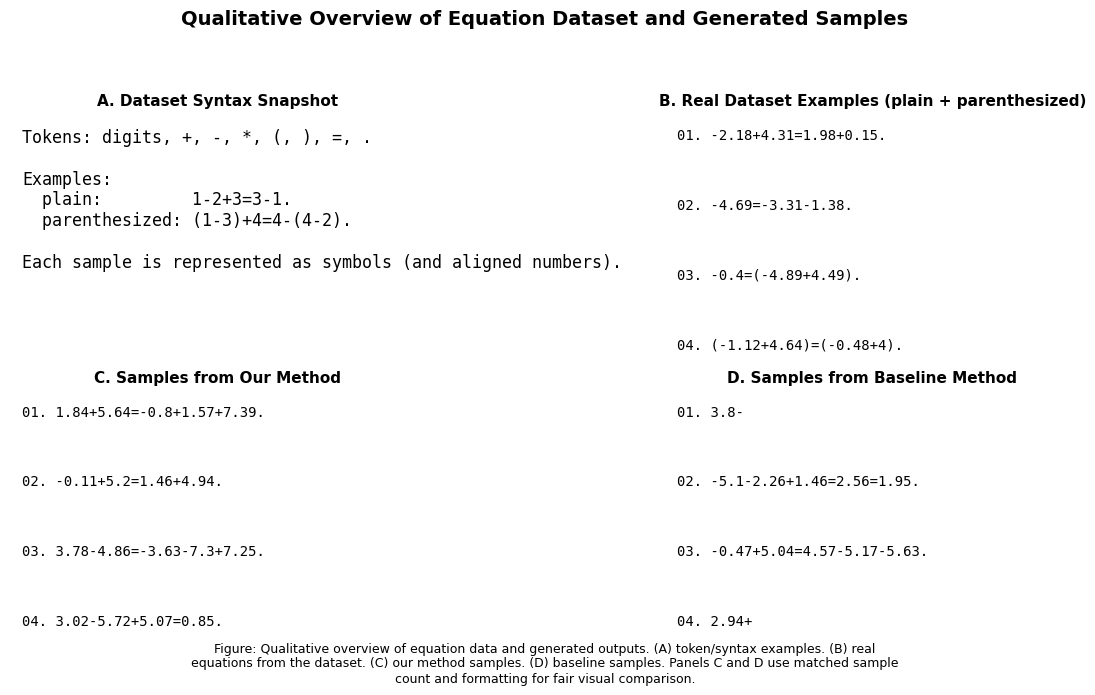

Saved: figures/dataset_overview_qualitative.png
Saved: figures/dataset_overview_qualitative.pdf
Real plain source: data/equations_l5.jsonl
Real parenthesized source: data/parenthesis/equations_l5.jsonl
Our samples source: samples_toy/equations_l8_2ndorder_500/samples.jsonl
Baseline source: branching_flows_samples/equations_l8_gen.jsonl


In [10]:
from pathlib import Path
import json
import random
import textwrap
import matplotlib.pyplot as plt

# -----------------------------
# Configuration
# -----------------------------
FIG_CFG = {
    # Reproducibility
    "seed": 7,

    # Panel counts (smaller for readability)
    "n_real_total": 4,
    "n_generated_each": 4,

    # Figure sizing
    "figsize": (11, 7),
    "equation_fontsize": 10,
    "title_fontsize": 11,
    "max_chars_per_equation": 26,
    # Prefer sampling equations that already fit in one line.
    "sample_max_chars": 26,

    # Paths to candidate source files. The first existing path is used.
    # Update these to your exact experiment files as needed.
    "real_plain_candidates": [
        "data/equations_l5.jsonl",
        "data/equations_l8.jsonl",
    ],
    "real_parenthesized_candidates": [
        "data/parenthesis/equations_l5.jsonl",
        "data/parenthesis/equations_l8.jsonl",
    ],
    "ours_candidates": [
        "samples_toy/equations_l8_2ndorder_500/samples.jsonl",
        "samples-parenthesis/samples.json",
    ],
    "baseline_candidates": [
        "branching_flows_samples/equations_l8_gen.jsonl",
        "branching_flows_samples/equations_l10_gen.jsonl",
    ],

    # Output
    "save_png": "figures/dataset_overview_qualitative.png",
    "save_pdf": "figures/dataset_overview_qualitative.pdf",
}


def _resolve_first_existing(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None


def _symbols_to_equation(symbols):
    if not symbols:
        return ""
    eq = "".join(str(tok) for tok in symbols)
    return eq.strip()


def _format_number(value):
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)

    if abs(x - round(x)) < 1e-6:
        return str(int(round(x)))
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _numbers_symbols_to_equation(numbers, symbols):
    if not isinstance(symbols, list) or not symbols:
        return ""
    if not isinstance(numbers, list):
        numbers = []

    out = []
    n_idx = 0
    for tok in symbols:
        tok = str(tok)
        if tok in {"(", ")"}:
            out.append(tok)
            continue

        if n_idx < len(numbers):
            out.append(_format_number(numbers[n_idx]))
            n_idx += 1
        out.append(tok)

    eq = "".join(out)
    return eq.strip()


def _load_equations_from_jsonl(path):
    eqs = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            if "equation" in item and isinstance(item["equation"], str):
                eq = item["equation"].strip()
            elif "numbers" in item and "symbols" in item:
                eq = _numbers_symbols_to_equation(item["numbers"], item["symbols"])
            elif "symbols" in item:
                eq = _symbols_to_equation(item["symbols"])
            else:
                continue
            if eq:
                eqs.append(eq)
    return eqs


def _load_equations_from_json(path):
    data = json.loads(path.read_text())
    eqs = []

    # Equation-style JSON list
    if isinstance(data, list):
        for item in data:
            if isinstance(item, dict):
                if "equation" in item:
                    eqs.append(str(item["equation"]).strip())
                elif "numbers" in item and "symbols" in item:
                    eqs.append(_numbers_symbols_to_equation(item["numbers"], item["symbols"]))
                elif "symbols" in item:
                    eqs.append(_symbols_to_equation(item["symbols"]))
        return [e for e in eqs if e]

    # Dict-based format
    if isinstance(data, dict):
        if "equations" in data and isinstance(data["equations"], list):
            for item in data["equations"]:
                if isinstance(item, str):
                    eqs.append(item.strip())
                elif isinstance(item, dict):
                    if "equation" in item:
                        eqs.append(str(item["equation"]).strip())
                    elif "numbers" in item and "symbols" in item:
                        eqs.append(_numbers_symbols_to_equation(item["numbers"], item["symbols"]))
                    elif "symbols" in item:
                        eqs.append(_symbols_to_equation(item["symbols"]))
            return [e for e in eqs if e]

        # sampling.py QM9 format is not equation data; fail clearly.
        if "molecules" in data:
            raise ValueError(
                f"{path} appears to be QM9 molecule output (contains 'molecules'), not equation samples."
            )

    return [e for e in eqs if e]


def _load_equations_auto(path):
    suffix = path.suffix.lower()
    if suffix == ".jsonl":
        return _load_equations_from_jsonl(path)
    if suffix == ".json":
        return _load_equations_from_json(path)
    raise ValueError(f"Unsupported file type for equation loading: {path}")


def _sample_unique(items, n, rng):
    if not items:
        return []
    dedup = list(dict.fromkeys(items))
    if len(dedup) <= n:
        return dedup
    return rng.sample(dedup, n)


def _sample_short_equations(items, n, rng, max_chars):
    if not items:
        return []

    dedup = list(dict.fromkeys(items))
    short_pool = [eq for eq in dedup if len(eq) <= max_chars]

    # Prefer equations that fit in one line; if not enough, backfill with shortest remaining.
    if len(short_pool) >= n:
        return _sample_unique(short_pool, n, rng)

    remaining = [eq for eq in dedup if eq not in set(short_pool)]
    remaining_sorted = sorted(remaining, key=len)
    needed = max(0, n - len(short_pool))
    return short_pool + remaining_sorted[:needed]


def _truncate_text(text, max_chars):
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 1] + "..."


def _draw_equation_grid(ax, title, equations, n_cols=2, fontsize=10, max_chars=26, title_fontsize=11):
    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", pad=8)
    ax.axis("off")

    if not equations:
        ax.text(0.5, 0.5, "No equations found", ha="center", va="center", fontsize=fontsize)
        return

    n = len(equations)
    n_rows = (n + n_cols - 1) // n_cols

    # Looser layout with more room per equation.
    x_positions = [0.03 + i * (0.96 / max(n_cols - 1, 1)) for i in range(n_cols)]
    y_positions = [0.95 - i * (0.88 / max(n_rows - 1, 1)) for i in range(n_rows)]

    for idx, eq in enumerate(equations):
        r = idx // n_cols
        c = idx % n_cols
        safe_eq = _truncate_text(eq, max_chars)
        label = f"{idx + 1:02d}. {safe_eq}"
        ax.text(
            x_positions[c],
            y_positions[r],
            label,
            ha="left",
            va="top",
            fontsize=fontsize,
            family="monospace",
            clip_on=True,
        )


def build_qualitative_dataset_figure(cfg):
    rng = random.Random(cfg["seed"])

    real_plain_path = _resolve_first_existing(cfg["real_plain_candidates"])
    real_paren_path = _resolve_first_existing(cfg["real_parenthesized_candidates"])
    ours_path = _resolve_first_existing(cfg["ours_candidates"])
    baseline_path = _resolve_first_existing(cfg["baseline_candidates"])

    missing = []
    if real_plain_path is None:
        missing.append("real_plain_candidates")
    if real_paren_path is None:
        missing.append("real_parenthesized_candidates")
    if ours_path is None:
        missing.append("ours_candidates")
    if baseline_path is None:
        missing.append("baseline_candidates")
    if missing:
        raise FileNotFoundError(
            "Missing source files for: "
            + ", ".join(missing)
            + ". Update FIG_CFG candidate paths to existing files."
        )

    real_plain = _load_equations_auto(real_plain_path)
    real_paren = _load_equations_auto(real_paren_path)
    ours = _load_equations_auto(ours_path)
    baseline = _load_equations_auto(baseline_path)

    n_real_total = cfg["n_real_total"]
    n_each_real_group = max(1, n_real_total // 2)
    n_generated_each = cfg["n_generated_each"]

    sample_max_chars = cfg["sample_max_chars"]

    real_plain_pick = _sample_short_equations(real_plain, n_each_real_group, rng, sample_max_chars)
    real_paren_pick = _sample_short_equations(
        real_paren,
        n_real_total - len(real_plain_pick),
        rng,
        sample_max_chars,
    )
    real_panel = real_plain_pick + real_paren_pick

    ours_panel = _sample_short_equations(ours, n_generated_each, rng, sample_max_chars)
    baseline_panel = _sample_short_equations(baseline, n_generated_each, rng, sample_max_chars)

    fig, axs = plt.subplots(2, 2, figsize=cfg["figsize"])
    fig.suptitle("Qualitative Overview of Equation Dataset and Generated Samples", fontsize=14, fontweight="bold")

    # Panel A: syntax snapshot
    axs[0, 0].axis("off")
    axs[0, 0].set_title("A. Dataset Syntax Snapshot", fontsize=cfg["title_fontsize"], fontweight="bold", pad=8)
    syntax_text = "\n".join(
        [
            "Tokens: digits, +, -, *, (, ), =, .",
            "",
            "Examples:",
            "  plain:         1-2+3=3-1.",
            "  parenthesized: (1-3)+4=4-(4-2).",
            "",
            "Each sample is represented as symbols (and aligned numbers).",
        ]
    )
    axs[0, 0].text(0.03, 0.95, syntax_text, ha="left", va="top", fontsize=12, family="monospace")

    # Panel B/C/D grids
    _draw_equation_grid(
        axs[0, 1],
        "B. Real Dataset Examples (plain + parenthesized)",
        real_panel,
        n_cols=1,
        fontsize=cfg["equation_fontsize"],
        max_chars=cfg["max_chars_per_equation"],
        title_fontsize=cfg["title_fontsize"],
    )
    _draw_equation_grid(
        axs[1, 0],
        "C. Samples from Our Method",
        ours_panel,
        n_cols=1,
        fontsize=cfg["equation_fontsize"],
        max_chars=cfg["max_chars_per_equation"],
        title_fontsize=cfg["title_fontsize"],
    )
    _draw_equation_grid(
        axs[1, 1],
        "D. Samples from Baseline Method",
        baseline_panel,
        n_cols=1,
        fontsize=cfg["equation_fontsize"],
        max_chars=cfg["max_chars_per_equation"],
        title_fontsize=cfg["title_fontsize"],
    )

    caption = (
        "Figure: Qualitative overview of equation data and generated outputs. "
        "(A) token/syntax examples. (B) real equations from the dataset. "
        "(C) our method samples. (D) baseline samples. "
        "Panels C and D use matched sample count and formatting for fair visual comparison."
    )
    fig.text(0.5, 0.015, textwrap.fill(caption, width=110), ha="center", va="bottom", fontsize=9)

    plt.tight_layout(rect=[0, 0.07, 1, 0.93])

    png_path = Path(cfg["save_png"])
    pdf_path = Path(cfg["save_pdf"])
    png_path.parent.mkdir(parents=True, exist_ok=True)
    pdf_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    print(f"Real plain source: {real_plain_path}")
    print(f"Real parenthesized source: {real_paren_path}")
    print(f"Our samples source: {ours_path}")
    print(f"Baseline source: {baseline_path}")


build_qualitative_dataset_figure(FIG_CFG)


## Paper Figure: Stylized Version (structured + failure-ready)

This is a second, independent figure cell. It keeps the original version untouched and adds:

- stronger visual design (custom palette + panel cards),
- explicit structure for panel-level control,
- baseline sample annotation hooks for common failure highlighting.

/tmp/ipykernel_145023/3928604762.py:679: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.03, 0.99, 0.94])


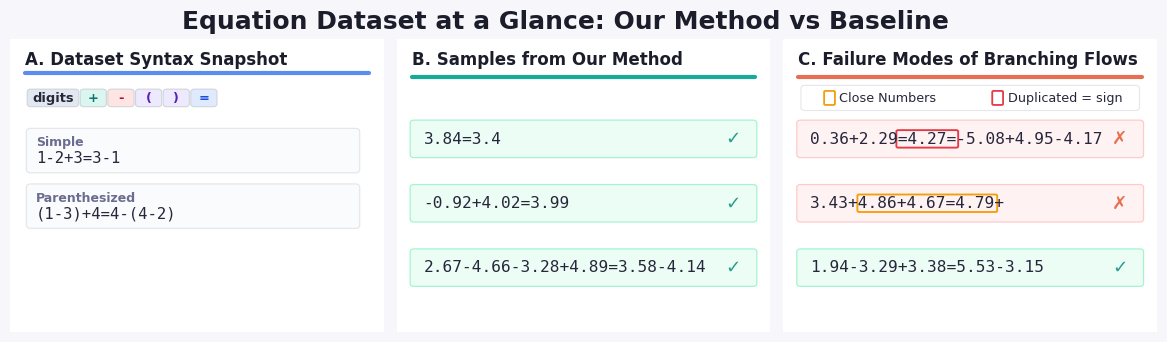

Saved: figures/dataset_overview_stylish.png
Saved: figures/dataset_overview_stylish.pdf
Our samples source: samples_toy/equations_l8_2ndorder_500/samples.jsonl
Baseline source: branching_flows_samples/equations_l8_gen.jsonl


In [70]:
from pathlib import Path
import json
import random
import ast
import re
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.font_manager import FontProperties

# -------------------------------------------------------------------
# Stylish figure config (edit this block to art-direct the figure)
# -------------------------------------------------------------------
STYLISH_CFG = {
    "seed": 15,
    "n_real_total": 5,
    "n_generated_each": 5,
    "ours_target_correct": 3,
    "baseline_target_examples": 3,
    "sample_max_chars": 30,
    "max_chars_per_equation": 34,
    "figsize": (14.8, 3.8),
    "dpi": 400,
    "equation_fontsize": 11.6,
    "equation_fontfamily": "DejaVu Sans Mono",
    "title": "Equation Dataset at a Glance: Our Method vs Baseline",
    "show_quality_badges": True,
    "show_failure_flags": True,
    "quality_tolerance": 1.0,
    "close_number_delta": 0.50,
    "highlight_issue_boxes": True,
    "save_png": "figures/dataset_overview_stylish.png",
    "save_pdf": "figures/dataset_overview_stylish.pdf",
    "palette": {
        "figure_bg": "#f7f7fb",
        "card_bg": "#ffffff",
        "card_edge": "#d9d7f8",
        "title": "#1c1d2b",
        "subtitle": "#4b4e6d",
        "body": "#26273a",
        "muted": "#6a6d8f",
        "accent_real": "#5b8def",
        "accent_ours": "#18a999",
        "accent_base": "#e76f51",
        "ok": "#2a9d8f",
        "warn": "#e76f51",
        "box_close": "#F59E0B",
        "box_double_equal": "#e63946",
    },
    "real_plain_candidates": [
        "data/equations_l5.jsonl",
        "data/equations_l8.jsonl",
    ],
    "ours_candidates": [
        "samples_toy/equations_l8_2ndorder_500/samples.jsonl",
        "samples_toy/equations_l8_2ndorder_1000/samples.jsonl",
    ],
    "baseline_candidates": [
        "branching_flows_samples/equations_l8_gen.jsonl",
        "branching_flows_samples/equations_l10_gen.jsonl",
    ],
}


def _resolve_first_existing(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None


def _format_number(value):
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if abs(x - round(x)) < 1e-6:
        return str(int(round(x)))
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _symbols_to_equation(symbols):
    if not symbols:
        return ""
    return "".join(str(tok) for tok in symbols).strip()


def _numbers_symbols_to_equation(numbers, symbols):
    if not isinstance(symbols, list) or not symbols:
        return ""
    if not isinstance(numbers, list):
        numbers = []
    out = []
    n_idx = 0
    for tok in symbols:
        tok = str(tok)
        if tok in {"(", ")"}:
            out.append(tok)
            continue
        if n_idx < len(numbers):
            out.append(_format_number(numbers[n_idx]))
            n_idx += 1
        out.append(tok)
    return "".join(out).strip()


def _load_equations_auto(path):
    suffix = path.suffix.lower()
    if suffix == ".jsonl":
        eqs = []
        with path.open("r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                item = json.loads(line)
                if "equation" in item and isinstance(item["equation"], str):
                    eq = item["equation"].strip()
                elif "numbers" in item and "symbols" in item:
                    eq = _numbers_symbols_to_equation(item["numbers"], item["symbols"])
                elif "symbols" in item:
                    eq = _symbols_to_equation(item["symbols"])
                else:
                    continue
                if eq:
                    eqs.append(eq)
        return eqs

    if suffix == ".json":
        data = json.loads(path.read_text())
        eqs = []
        if isinstance(data, list):
            for item in data:
                if not isinstance(item, dict):
                    continue
                if "equation" in item:
                    eqs.append(str(item["equation"]).strip())
                elif "numbers" in item and "symbols" in item:
                    eqs.append(_numbers_symbols_to_equation(item["numbers"], item["symbols"]))
                elif "symbols" in item:
                    eqs.append(_symbols_to_equation(item["symbols"]))
            return [e for e in eqs if e]
        if isinstance(data, dict) and "molecules" in data:
            raise ValueError(f"{path} is QM9 molecule output, not equation data.")
        return [e for e in eqs if e]

    raise ValueError(f"Unsupported file type: {path}")


def _sample_short_equations(items, n, rng, max_chars):
    if not items:
        return []
    dedup = list(dict.fromkeys(items))
    short_pool = [eq for eq in dedup if len(eq) <= max_chars]
    if len(short_pool) >= n:
        return rng.sample(short_pool, n)
    remain = sorted([eq for eq in dedup if eq not in set(short_pool)], key=len)
    return short_pool + remain[: max(0, n - len(short_pool))]


def _clean_equation_display(eq):
    return eq.strip().rstrip(".")


def _truncate(text, max_chars):
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3] + "..."


def _truncate_spans(spans, visible_len):
    out = []
    for start, end in spans:
        if start >= visible_len:
            continue
        out.append((start, min(end, visible_len)))
    return out


def _merge_spans(spans, gap=0):
    if not spans:
        return []
    spans_sorted = sorted(spans, key=lambda s: (s[0], s[1]))
    merged = [list(spans_sorted[0])]
    for start, end in spans_sorted[1:]:
        prev = merged[-1]
        if start <= prev[1] + gap:
            prev[1] = max(prev[1], end)
        else:
            merged.append([start, end])
    return [(s, e) for s, e in merged]


def _find_issue_spans(eq, close_number_delta=0.20):
    close_spans = []
    double_eq_spans = []

    # 1) very close neighboring numbers -> contiguous region across both numbers
    num_matches = list(re.finditer(r"-?\d+(?:\.\d+)?", eq))
    for i in range(len(num_matches) - 1):
        a = float(num_matches[i].group())
        b = float(num_matches[i + 1].group())
        if abs(a - b) <= close_number_delta:
            close_spans.append((num_matches[i].start(), num_matches[i + 1].end()))

    # 2a) literal repeated equals: "==", "===", ...
    for m in re.finditer(r"={2,}", eq):
        double_eq_spans.append(m.span())

    # 2b) multiple equals separated by text: e.g., "1-2=3=4"
    eq_positions = [idx for idx, ch in enumerate(eq) if ch == "="]
    if len(eq_positions) >= 2 and not double_eq_spans:
        double_eq_spans.append((eq_positions[0], eq_positions[-1] + 1))

    return {
        "close_numbers": _merge_spans(close_spans, gap=1),
        "double_equal": _merge_spans(double_eq_spans, gap=0),
    }


def _safe_eval_arith(expr):
    node = ast.parse(expr, mode="eval")

    def _eval(n):
        if isinstance(n, ast.Expression):
            return _eval(n.body)
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return float(n.value)
        if isinstance(n, ast.UnaryOp) and isinstance(n.op, (ast.UAdd, ast.USub)):
            val = _eval(n.operand)
            return val if isinstance(n.op, ast.UAdd) else -val
        if isinstance(n, ast.BinOp) and isinstance(n.op, (ast.Add, ast.Sub, ast.Mult)):
            left = _eval(n.left)
            right = _eval(n.right)
            if isinstance(n.op, ast.Add):
                return left + right
            if isinstance(n.op, ast.Sub):
                return left - right
            return left * right
        raise ValueError("Unsupported expression")

    return _eval(node)


def _equation_error(eq):
    if "=" not in eq:
        return None
    clean = eq.strip().rstrip(".")
    left, right = clean.split("=", 1)
    if not left.strip() or not right.strip():
        return None
    try:
        lval = _safe_eval_arith(left)
        rval = _safe_eval_arith(right)
    except Exception:
        return None
    return abs(lval - rval)


def _extract_numbers(eq):
    return [float(m.group()) for m in re.finditer(r"-?\d+(?:\.\d+)?", eq)]


def _has_double_equal(eq):
    return eq.count("=") >= 2 or "==" in eq


def _has_long_close_sequence(eq, delta=0.20, min_run=3):
    nums = _extract_numbers(eq)
    if len(nums) < min_run:
        return False
    run = 1
    for i in range(len(nums) - 1):
        if abs(nums[i] - nums[i + 1]) <= delta:
            run += 1
            if run >= min_run:
                return True
        else:
            run = 1
    return False


def _is_correct_equation(eq, tolerance=0.25):
    clean = _clean_equation_display(eq)
    if clean.count("=") != 1:
        return False
    if clean.count("(") != clean.count(")"):
        return False
    if clean.endswith(("+", "-", "*", "=")):
        return False
    err = _equation_error(clean)
    return err is not None and err <= tolerance


def _pick_curated_examples(ours, baseline, cfg, rng):
    max_chars = cfg["sample_max_chars"]
    tol = cfg["quality_tolerance"]
    delta = cfg["close_number_delta"]

    ours_pool = [
        eq
        for eq in dict.fromkeys(ours)
        if len(_clean_equation_display(eq)) <= max_chars and _is_correct_equation(eq, tolerance=tol)
    ]
    ours_target = cfg.get("ours_target_correct", 3)
    if len(ours_pool) >= ours_target:
        ours_panel = rng.sample(ours_pool, ours_target)
    else:
        ours_panel = ours_pool + _sample_short_equations(ours, ours_target - len(ours_pool), rng, max_chars)

    baseline_dedup = [eq for eq in dict.fromkeys(baseline) if len(_clean_equation_display(eq)) <= max_chars]
    baseline_panel = []

    def _pick_first(predicate):
        for eq in baseline_dedup:
            if eq in baseline_panel:
                continue
            if predicate(eq):
                baseline_panel.append(eq)
                return

    _pick_first(lambda eq: _has_double_equal(_clean_equation_display(eq)))
    _pick_first(lambda eq: _has_long_close_sequence(_clean_equation_display(eq), delta=delta, min_run=3))
    _pick_first(lambda eq: _is_correct_equation(eq, tolerance=tol))

    target = cfg.get("baseline_target_examples", 3)
    if len(baseline_panel) < target:
        fillers = [eq for eq in baseline_dedup if eq not in baseline_panel]
        baseline_panel.extend(fillers[: target - len(baseline_panel)])

    return ours_panel, baseline_panel[:target]


def _detect_baseline_issues(eq):
    issues = []
    if "=" not in eq:
        issues.append("no_equal")
    if eq.count("(") != eq.count(")"):
        issues.append("unbalanced_paren")

    # Incomplete tails like "3.8-" or "2.9+" are common model failures.
    tail = eq.strip()
    if tail.endswith(("+", "-", "*", "=")):
        issues.append("incomplete_tail")

    if eq.count("=") >= 2:
        issues.append("double_equal")

    return issues


def _add_card(ax, face, edge):
    card = FancyBboxPatch(
        (0.0, 0.0),
        1.0,
        1.0,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        transform=ax.transAxes,
        linewidth=1.4,
        edgecolor=edge,
        facecolor=face,
        zorder=0,
    )
    ax.add_patch(card)


def _draw_list_panel(
    ax,
    title,
    equations,
    palette,
    title_accent,
    max_chars=34,
    show_failure_flags=False,
    show_quality_badges=False,
    quality_tolerance=0.25,
    highlight_issue_boxes=True,
    close_number_delta=0.20,
    reserve_top_space=False,
    show_success_marks=False,
    equation_fontsize=11.6,
    equation_fontfamily="DejaVu Sans Mono",
    subtitle=None,
):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])

    ax.text(0.04, 0.93, title, ha="left", va="center", fontsize=12, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.872, 0.872], lw=3, color=title_accent, solid_capstyle="round")

    if not equations:
        ax.text(0.5, 0.5, "No equations found", ha="center", va="center", fontsize=11, color=palette["muted"])
        return

    show_issue_legend = bool(show_failure_flags)
    if show_issue_legend:
        # Centered horizontal legend in a dedicated strip.
        strip = FancyBboxPatch(
            (0.05, 0.76),
            0.90,
            0.08,
            boxstyle="round,pad=0.003,rounding_size=0.010",
            linewidth=0.8,
            edgecolor="#E5E7EB",
            facecolor="#FFFFFF",
            transform=ax.transAxes,
        )
        ax.add_patch(strip)

        leg_y = 0.80
        box_w = 0.027
        box_h = 0.046
        first_x = 0.11
        second_x = 0.56
        label_dx = 0.040

        box_close = FancyBboxPatch(
            (first_x, leg_y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.001,rounding_size=0.004",
            linewidth=1.3,
            edgecolor=palette["box_close"],
            facecolor="none",
            transform=ax.transAxes,
        )
        ax.add_patch(box_close)
        ax.text(first_x + label_dx, leg_y, "Close Numbers", ha="left", va="center", fontsize=9.2, color=palette["body"])

        box_eq = FancyBboxPatch(
            (second_x, leg_y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.001,rounding_size=0.004",
            linewidth=1.3,
            edgecolor=palette["box_double_equal"],
            facecolor="none",
            transform=ax.transAxes,
        )
        ax.add_patch(box_eq)
        ax.text(second_x + label_dx, leg_y, "Duplicated = sign", ha="left", va="center", fontsize=9.2, color=palette["body"])

    y0 = 0.66 if (show_issue_legend or reserve_top_space) else 0.80
    y_bottom = 0.22
    if len(equations) <= 1:
        y_positions = [0.5 * (y0 + y_bottom)]
    else:
        ystep = (y0 - y_bottom) / (len(equations) - 1)
        y_positions = [y0 - i * ystep for i in range(len(equations))]

    text_fontsize = equation_fontsize
    text_family = equation_fontfamily

    # Use renderer-measured glyph widths for accurate highlight placement.
    ax.figure.canvas.draw()
    renderer = ax.figure.canvas.get_renderer()
    fp = FontProperties(family=text_family, size=text_fontsize)

    def _px_to_ax_dx(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((px, 0))
        return p1[0] - p0[0]

    def _px_to_ax_dy(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((0, px))
        return p1[1] - p0[1]

    for i, eq in enumerate(equations):
        y = y_positions[i]
        eq_clean = _clean_equation_display(eq)
        text = _truncate(eq_clean, max_chars)

        issue_found = False

        if show_quality_badges:
            err = _equation_error(eq_clean)
            if err is None or err > quality_tolerance:
                issue_found = True

        if show_failure_flags and _detect_baseline_issues(eq_clean):
            issue_found = True

        # Row micro-card with semantic color (replaces VALID/ISSUE text badges).
        row_h = 0.12 if len(equations) <= 3 else 0.10
        if issue_found:
            row_face = "#FEF2F2"
            row_edge = "#FECACA"
        elif show_success_marks:
            row_face = "#ECFDF5"
            row_edge = "#A7F3D0"
        else:
            row_face = "#F8FAFC"
            row_edge = "#E5E7EB"

        row_card = FancyBboxPatch(
            (0.04, y - row_h / 2),
            0.92,
            row_h,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.9,
            edgecolor=row_edge,
            facecolor=row_face,
            zorder=1,
            transform=ax.transAxes,
        )
        ax.add_patch(row_card)

        text_x = 0.072
        ax.text(text_x, y, text, ha="left", va="center", fontsize=text_fontsize, family=text_family, color=palette["body"], zorder=4)

        if highlight_issue_boxes:
            issue_spans = _find_issue_spans(eq_clean, close_number_delta=close_number_delta)
            color_map = {
                "close_numbers": palette["box_close"],
                "double_equal": palette["box_double_equal"],
            }

            _, text_h_px, _ = renderer.get_text_width_height_descent(text, fp, ismath=False)
            box_h = _px_to_ax_dy(text_h_px) * 1.35

            for issue_type, spans in issue_spans.items():
                visible_spans = _truncate_spans(spans, len(text))
                for start, end in visible_spans:
                    if end <= start:
                        continue

                    prefix = text[:start]
                    segment = text[start:end]
                    prefix_w_px, _, _ = renderer.get_text_width_height_descent(prefix, fp, ismath=False)
                    segment_w_px, _, _ = renderer.get_text_width_height_descent(segment, fp, ismath=False)

                    x = text_x + _px_to_ax_dx(prefix_w_px)
                    w = max(_px_to_ax_dx(segment_w_px), _px_to_ax_dx(6.0))

                    box = FancyBboxPatch(
                        (x - 0.0022, y - box_h / 2),
                        w + 0.0044,
                        box_h,
                        boxstyle="round,pad=0.0022,rounding_size=0.0048",
                        linewidth=1.35,
                        edgecolor=color_map.get(issue_type, palette["warn"]),
                        facecolor="none",
                        zorder=2,
                    )
                    ax.add_patch(box)

        # Add explicit marks for readability on top of color encoding.
        if issue_found:
            ax.text(0.90, y, "✗", ha="center", va="center", fontsize=13.2, color=palette["warn"], fontweight="bold", zorder=4)
        elif show_success_marks:
            ax.text(0.90, y, "✓", ha="center", va="center", fontsize=13.2, color=palette["ok"], fontweight="bold", zorder=4)


def build_stylish_overview_figure(cfg):
    rng = random.Random(cfg["seed"])
    palette = cfg["palette"]

    ours_path = _resolve_first_existing(cfg["ours_candidates"])
    baseline_path = _resolve_first_existing(cfg["baseline_candidates"])

    missing = []
    if ours_path is None:
        missing.append("ours_candidates")
    if baseline_path is None:
        missing.append("baseline_candidates")
    if missing:
        raise FileNotFoundError("Missing source files for: " + ", ".join(missing))

    ours = _load_equations_auto(ours_path)
    baseline = _load_equations_auto(baseline_path)

    ours_panel, baseline_panel = _pick_curated_examples(ours, baseline, cfg, rng)

    fig, axs = plt.subplots(
        1,
        3,
        figsize=cfg["figsize"],
        facecolor=palette["figure_bg"],
        gridspec_kw={"wspace": 0.035},
    )

    fig.suptitle(cfg["title"], fontsize=18, fontweight="bold", color=palette["title"], y=0.958)

    # Panel A (syntax card)
    ax = axs[0]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])
    ax.text(0.04, 0.93, "A. Dataset Syntax Snapshot", ha="left", va="center", fontsize=12, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.885, 0.885], lw=3, color=palette["accent_real"], solid_capstyle="round")

    # Token chips row
    chip_y = 0.80
    chips = [
        ("digits", "#E2E8F0", palette["body"]),
        ("+", "#DBF5EF", "#0F766E"),
        ("-", "#FEE4E2", "#9F1239"),
        # ("*", "#FEF3C7", "#92400E"),
        ("(", "#EDE9FE", "#5B21B6"),
        (")", "#EDE9FE", "#5B21B6"),
        ("=", "#E0EAFF", "#1D4ED8"),
    ]
    x = 0.05
    for label, face, tcolor in chips:
        w = 0.062 if len(label) <= 2 else 0.13
        chip = FancyBboxPatch(
            (x, chip_y - 0.026),
            w,
            0.052,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.8,
            edgecolor="#D1D5DB",
            facecolor=face,
            transform=ax.transAxes,
        )
        ax.add_patch(chip)
        ax.text(x + w / 2, chip_y, label, ha="center", va="center", fontsize=9.4, color=tcolor, fontweight="semibold")
        x += w + 0.012

    # Example cards
    card_specs = [
        ("Simple", "1-2+3=3-1", 0.05, 0.55),
        ("Parenthesized", "(1-3)+4=4-(4-2)", 0.05, 0.36),
    ]
    for title, eq, x0, y0 in card_specs:
        card = FancyBboxPatch(
            (x0, y0),
            0.88,
            0.14,
            boxstyle="round,pad=0.006,rounding_size=0.012",
            linewidth=0.9,
            edgecolor="#E5E7EB",
            facecolor="#FAFBFD",
            transform=ax.transAxes,
        )
        ax.add_patch(card)
        ax.text(x0 + 0.02, y0 + 0.098, title, ha="left", va="center", fontsize=9.0, color=palette["muted"], fontweight="semibold")
        ax.text(x0 + 0.02, y0 + 0.044, eq, ha="left", va="center", fontsize=11.2, family=cfg["equation_fontfamily"], color=palette["body"])

    _draw_list_panel(
        axs[1],
        "B. Samples from Our Method",
        ours_panel,
        palette,
        palette["accent_ours"],
        max_chars=cfg["max_chars_per_equation"],
        show_quality_badges=cfg["show_quality_badges"],
        quality_tolerance=cfg["quality_tolerance"],
        highlight_issue_boxes=False,
        close_number_delta=cfg["close_number_delta"],
        reserve_top_space=cfg["show_failure_flags"],
        show_success_marks=True,
        equation_fontsize=cfg["equation_fontsize"],
        equation_fontfamily=cfg["equation_fontfamily"],
    )
    _draw_list_panel(
        axs[2],
        "C. Failure Modes of Branching Flows",
        baseline_panel,
        palette,
        palette["accent_base"],
        max_chars=cfg["max_chars_per_equation"],
        show_quality_badges=cfg["show_quality_badges"],
        quality_tolerance=cfg["quality_tolerance"],
        show_failure_flags=cfg["show_failure_flags"],
        highlight_issue_boxes=cfg["highlight_issue_boxes"],
        close_number_delta=cfg["close_number_delta"],
        reserve_top_space=cfg["show_failure_flags"],
        show_success_marks=True,
        equation_fontsize=cfg["equation_fontsize"],
        equation_fontfamily=cfg["equation_fontfamily"],
    )

    plt.tight_layout(rect=[0.01, 0.03, 0.99, 0.94])

    out_png = Path(cfg["save_png"])
    out_pdf = Path(cfg["save_pdf"])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=cfg["dpi"], bbox_inches="tight", facecolor=fig.get_facecolor())
    fig.savefig(out_pdf, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")
    print(f"Our samples source: {ours_path}")
    print(f"Baseline source: {baseline_path}")


build_stylish_overview_figure(STYLISH_CFG)